In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from numpy.fft import rfft, rfftfreq
from scipy import signal

fs = 10000 #Frequência de aquisição do sinal 10kHz

pontos_por_linha = 200 #Os sinais de vibração foram divididos em segmentos menores utilizando uma janela de 200 pontos de dados, 
                    #com o objetivo de reduzir o tempo computacional.

duracao_linha_s = pontos_por_linha / fs #Cada linha equivale a um pedaço do sinal 200/10000 = 20 ms

pasta_dados = Path("data")

In [163]:
#Eixo Z
vibracao_eixo_z = np.load('data/z_1500_10.npy')
#Eixo X
vibracao_eixo_x = np.load('data/x_1500_10.npy')
#Eixo Y
vibracao_eixo_y = np.load('data/y_1500_10.npy')


rotulos_amostras = np.load('data/gt_1500_10.npy')


In [164]:
print(f"O número de colunas eixo z: {len(vibracao_eixo_z[0])}")
print(f"O número de linhas eixo z: {len(vibracao_eixo_z)}")

print(f"O número de colunas eixo x: {len(vibracao_eixo_x[0])}")
print(f"O número de linhas eixo x: {len(vibracao_eixo_x)}")

print(f"O número de colunas eixo y: {len(vibracao_eixo_y[0])}")
print(f"O número de linhas eixo y: {len(vibracao_eixo_y)}")

print(f"O número de rótulos é: {len(rotulos_amostras)}")


O número de colunas eixo z: 200
O número de linhas eixo z: 50000
O número de colunas eixo x: 200
O número de linhas eixo x: 50000
O número de colunas eixo y: 200
O número de linhas eixo y: 50000
O número de rótulos é: 50000


In [165]:
df_vibracao_eixo_x = pd.DataFrame(vibracao_eixo_x)
df_vibracao_eixo_y = pd.DataFrame(vibracao_eixo_y)
df_vibracao_eixo_z = pd.DataFrame(vibracao_eixo_z)

# Adiciona a coluna de classe
df_vibracao_eixo_x["classe"] = rotulos_amostras
df_vibracao_eixo_y["classe"] = rotulos_amostras
df_vibracao_eixo_z["classe"] = rotulos_amostras

In [166]:
df_vibracao_eixo_x.head(3)

,0,1,2,3,4,5,6,7,8,9,...,191,192,193,194,195,196,197,198,199,classe
0,-0.032906,-0.037456,-0.034082,-0.001968,0.084229,0.156574,0.128887,0.042514,-0.036834,-0.013936,...,-0.099786,-0.080654,-0.070954,-0.003636,0.012660,0.028986,0.008340,0.065012,0.091692,3
1,0.198619,0.178949,0.072092,0.083383,0.151363,0.108910,-0.099102,-0.195660,-0.125213,0.042914,...,-0.135897,-0.024512,0.103591,0.168580,0.032522,0.117073,0.001361,0.060746,0.093414,0
2,-0.000792,0.012913,0.017356,0.024251,0.022153,0.019270,0.017725,0.013644,0.015150,0.020608,...,0.016042,0.014681,0.017848,0.015588,0.011422,0.008025,0.009931,0.006395,0.002775,0


In [167]:
df_vibracao_eixo_y.head(3)

,0,1,2,3,4,5,6,7,8,9,...,191,192,193,194,195,196,197,198,199,classe
0,-0.032458,-0.065895,-0.033437,0.023354,-0.050963,-0.079567,-0.158764,-0.225719,-0.146064,-0.081333,...,0.010493,-0.093568,-0.100504,-0.034874,-0.048169,-0.142620,-0.188990,-0.142274,-0.018007,3
1,-0.044002,-0.026300,-0.142555,-0.158291,-0.053877,0.194706,0.371975,0.349063,0.101813,-0.060733,...,-0.349464,-0.163123,-0.196713,-0.080442,-0.181516,-0.205376,0.074509,0.403759,0.612137,0
2,0.012965,0.018673,0.022848,0.019043,0.014483,0.016875,0.020697,0.016353,0.012179,0.009473,...,-0.017541,0.012973,0.039707,0.041048,0.023619,-0.007386,-0.034698,-0.041762,-0.034946,0


In [168]:
df_vibracao_eixo_z.head(3)

,0,1,2,3,4,5,6,7,8,9,...,191,192,193,194,195,196,197,198,199,classe
0,-0.182078,-0.165990,0.147757,0.096662,-0.056907,-0.310580,-0.470552,-0.273967,-0.233207,0.225104,...,0.328633,0.500143,0.550680,0.321061,0.138348,-0.058564,-0.195702,-0.276894,-0.288260,3
1,-0.065122,-0.232418,-0.464595,-0.510616,-0.201496,-0.074505,-0.114415,0.194517,0.411912,0.521579,...,0.268816,0.749696,-0.057662,0.055156,-0.692248,-0.331509,-0.041532,0.076351,0.128364,0
2,-0.057997,-0.030175,-0.005425,0.009177,0.013701,-0.011606,-0.009907,-0.016371,0.001897,0.010207,...,-0.039403,-0.042588,-0.008130,0.013023,0.004155,-0.002979,-0.005700,0.000764,0.010061,0


In [169]:
mapa_classes = {
    0: "Normal",
    1: "Desgaste Superficial",
    2: "Dente Trincado",
    3: "Dente Lascado",
    4: "Dente Ausente",
}

nomes_classes_ordenados = [mapa_classes[i] for i in sorted(mapa_classes)]
labels_classes_curtas = [f"Classe {i}" for i in sorted(mapa_classes)]

def rotulo_classe(classe):
    return f"{classe} - {mapa_classes.get(int(classe), 'Classe desconhecida')}"

#Separação por classes eixo X
df_vibracao_eixo_x_classe0 = df_vibracao_eixo_x[df_vibracao_eixo_x["classe"] == 0]
df_vibracao_eixo_x_classe1 = df_vibracao_eixo_x[df_vibracao_eixo_x["classe"] == 1]
df_vibracao_eixo_x_classe2 = df_vibracao_eixo_x[df_vibracao_eixo_x["classe"] == 2]
df_vibracao_eixo_x_classe3 = df_vibracao_eixo_x[df_vibracao_eixo_x["classe"] == 3]
df_vibracao_eixo_x_classe4 = df_vibracao_eixo_x[df_vibracao_eixo_x["classe"] == 4]
#Separação por classes eixo y
df_vibracao_eixo_y_classe0 = df_vibracao_eixo_y[df_vibracao_eixo_y["classe"] == 0]
df_vibracao_eixo_y_classe1 = df_vibracao_eixo_y[df_vibracao_eixo_y["classe"] == 1]
df_vibracao_eixo_y_classe2 = df_vibracao_eixo_y[df_vibracao_eixo_y["classe"] == 2]
df_vibracao_eixo_y_classe3 = df_vibracao_eixo_y[df_vibracao_eixo_y["classe"] == 3]
df_vibracao_eixo_y_classe4 = df_vibracao_eixo_y[df_vibracao_eixo_y["classe"] == 4]
#Separação por classes eixo z
df_vibracao_eixo_z_classe0 = df_vibracao_eixo_z[df_vibracao_eixo_z["classe"] == 0]
df_vibracao_eixo_z_classe1 = df_vibracao_eixo_z[df_vibracao_eixo_z["classe"] == 1]
df_vibracao_eixo_z_classe2 = df_vibracao_eixo_z[df_vibracao_eixo_z["classe"] == 2]
df_vibracao_eixo_z_classe3 = df_vibracao_eixo_z[df_vibracao_eixo_z["classe"] == 3]
df_vibracao_eixo_z_classe4 = df_vibracao_eixo_z[df_vibracao_eixo_z["classe"] == 4]

Gráfico salvo em: images\sinais_por_classe_eixo_x_200_00s.png


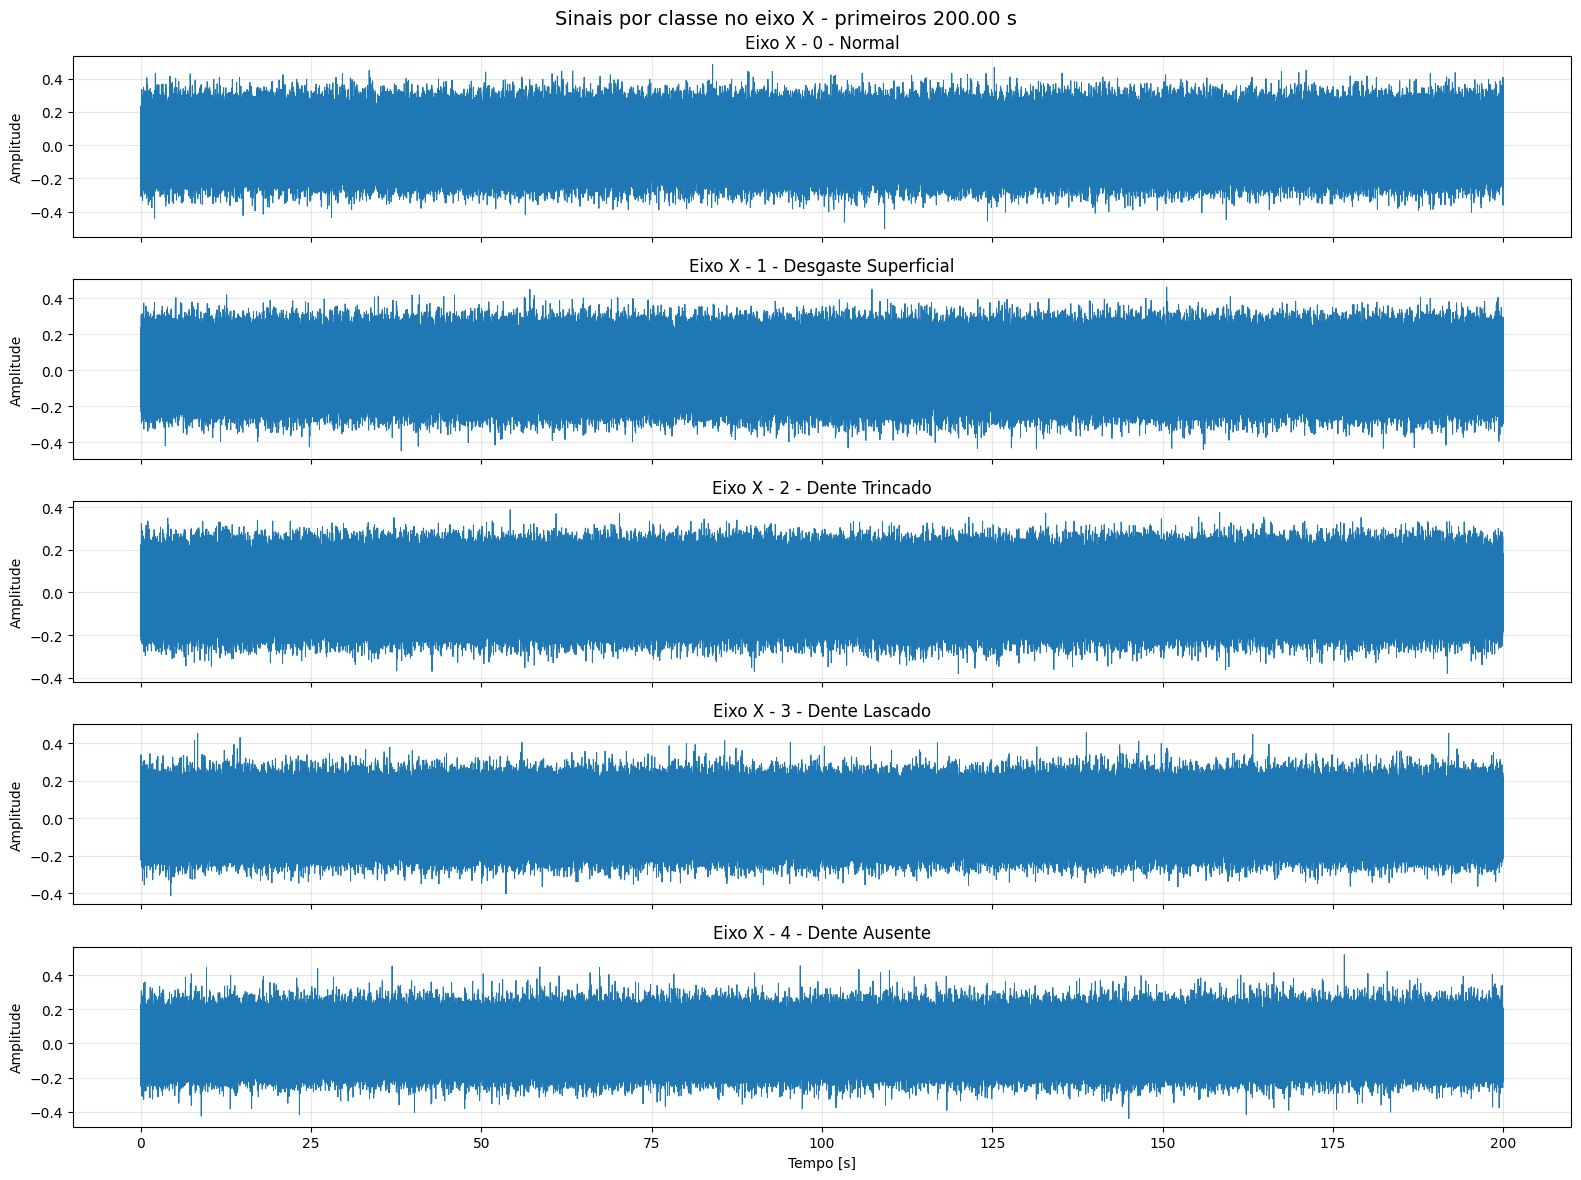

In [170]:
eixo_para_plot = "x"  # escolha entre "x", "y" ou "z"
duracao_plot_s = 200.0   # use None para plotar todo o sinal reconstruido da classe

classes_por_eixo = {
    "x": [df_vibracao_eixo_x_classe0, df_vibracao_eixo_x_classe1, df_vibracao_eixo_x_classe2, df_vibracao_eixo_x_classe3, df_vibracao_eixo_x_classe4],
    "y": [df_vibracao_eixo_y_classe0, df_vibracao_eixo_y_classe1, df_vibracao_eixo_y_classe2, df_vibracao_eixo_y_classe3, df_vibracao_eixo_y_classe4],
    "z": [df_vibracao_eixo_z_classe0, df_vibracao_eixo_z_classe1, df_vibracao_eixo_z_classe2, df_vibracao_eixo_z_classe3, df_vibracao_eixo_z_classe4],
}

fig, axes = plt.subplots(5, 1, figsize=(16, 12), sharex=True)

for classe, ax in enumerate(axes):
    df_classe = classes_por_eixo[eixo_para_plot][classe].drop(columns="classe")
    sinal_classe = df_classe.to_numpy().reshape(-1)

    if duracao_plot_s is None:
        amostras_plot = sinal_classe.size
    else:
        amostras_plot = min(int(duracao_plot_s * fs), sinal_classe.size)

    tempo_plot = np.arange(amostras_plot) / fs
    ax.plot(tempo_plot, sinal_classe[:amostras_plot], linewidth=0.7)
    ax.set_title(f"Eixo {eixo_para_plot.upper()} - {rotulo_classe(classe)}")
    ax.set_ylabel("Amplitude")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Tempo [s]")

if duracao_plot_s is None:
    titulo_figura = f"Sinais por classe no eixo {eixo_para_plot.upper()} - duracao completa"
    sufixo_arquivo = "duracao_completa"
else:
    titulo_figura = f"Sinais por classe no eixo {eixo_para_plot.upper()} - primeiros {duracao_plot_s:.2f} s"
    sufixo_arquivo = f"{duracao_plot_s:.2f}s".replace(".", "_")

fig.suptitle(titulo_figura, fontsize=14)
plt.tight_layout()

pasta_imagens = Path("images")
pasta_imagens.mkdir(exist_ok=True)
caminho_imagem = pasta_imagens / f"sinais_por_classe_eixo_{eixo_para_plot}_{sufixo_arquivo}.png"
fig.savefig(caminho_imagem, dpi=300, bbox_inches="tight")
print(f"Gráfico salvo em: {caminho_imagem}")

plt.show()


In [171]:
duracao_intervalo_s = 1.0

linhas_por_intervalo_exato = duracao_intervalo_s / duracao_linha_s
linhas_por_intervalo = int(linhas_por_intervalo_exato)
amostras_por_intervalo = linhas_por_intervalo * pontos_por_linha

segmentos_eixo_x_classe0 = df_vibracao_eixo_x_classe0.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_x_classe1 = df_vibracao_eixo_x_classe1.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_x_classe2 = df_vibracao_eixo_x_classe2.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_x_classe3 = df_vibracao_eixo_x_classe3.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_x_classe4 = df_vibracao_eixo_x_classe4.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)

segmentos_eixo_y_classe0 = df_vibracao_eixo_y_classe0.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_y_classe1 = df_vibracao_eixo_y_classe1.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_y_classe2 = df_vibracao_eixo_y_classe2.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_y_classe3 = df_vibracao_eixo_y_classe3.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_y_classe4 = df_vibracao_eixo_y_classe4.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)

segmentos_eixo_z_classe0 = df_vibracao_eixo_z_classe0.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_z_classe1 = df_vibracao_eixo_z_classe1.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_z_classe2 = df_vibracao_eixo_z_classe2.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_z_classe3 = df_vibracao_eixo_z_classe3.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_z_classe4 = df_vibracao_eixo_z_classe4.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)

segmentos_por_eixo_classe = {
    "x": {0: segmentos_eixo_x_classe0, 1: segmentos_eixo_x_classe1, 2: segmentos_eixo_x_classe2, 3: segmentos_eixo_x_classe3, 4: segmentos_eixo_x_classe4},
    "y": {0: segmentos_eixo_y_classe0, 1: segmentos_eixo_y_classe1, 2: segmentos_eixo_y_classe2, 3: segmentos_eixo_y_classe3, 4: segmentos_eixo_y_classe4},
    "z": {0: segmentos_eixo_z_classe0, 1: segmentos_eixo_z_classe1, 2: segmentos_eixo_z_classe2, 3: segmentos_eixo_z_classe3, 4: segmentos_eixo_z_classe4},
}

print(f"Duração do intervalo: {duracao_intervalo_s:.2f} s")
print(f"Linhas por intervalo: {linhas_por_intervalo}")
print(f"Amostras por intervalo: {amostras_por_intervalo}")

Duração do intervalo: 1.00 s
Linhas por intervalo: 50
Amostras por intervalo: 10000


In [172]:
resumo_segmentacao = pd.DataFrame({
    "eixo": ["x", "x", "x", "x", "x", "y", "y", "y", "y", "y", "z", "z", "z", "z", "z"],
    "classe": [0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4],
    "n_segmentos": [
        segmentos_eixo_x_classe0.shape[0], segmentos_eixo_x_classe1.shape[0], segmentos_eixo_x_classe2.shape[0], segmentos_eixo_x_classe3.shape[0], segmentos_eixo_x_classe4.shape[0],
        segmentos_eixo_y_classe0.shape[0], segmentos_eixo_y_classe1.shape[0], segmentos_eixo_y_classe2.shape[0], segmentos_eixo_y_classe3.shape[0], segmentos_eixo_y_classe4.shape[0],
        segmentos_eixo_z_classe0.shape[0], segmentos_eixo_z_classe1.shape[0], segmentos_eixo_z_classe2.shape[0], segmentos_eixo_z_classe3.shape[0], segmentos_eixo_z_classe4.shape[0],
    ],
    "amostras_por_segmento": [
        segmentos_eixo_x_classe0.shape[1], segmentos_eixo_x_classe1.shape[1], segmentos_eixo_x_classe2.shape[1], segmentos_eixo_x_classe3.shape[1], segmentos_eixo_x_classe4.shape[1],
        segmentos_eixo_y_classe0.shape[1], segmentos_eixo_y_classe1.shape[1], segmentos_eixo_y_classe2.shape[1], segmentos_eixo_y_classe3.shape[1], segmentos_eixo_y_classe4.shape[1],
        segmentos_eixo_z_classe0.shape[1], segmentos_eixo_z_classe1.shape[1], segmentos_eixo_z_classe2.shape[1], segmentos_eixo_z_classe3.shape[1], segmentos_eixo_z_classe4.shape[1],
    ],
})

resumo_segmentacao

,eixo,classe,n_segmentos,amostras_por_segmento
0,x,0,200,10000
1,x,1,200,10000
2,x,2,200,10000
3,x,3,200,10000
4,x,4,200,10000
5,y,0,200,10000
6,y,1,200,10000
7,y,2,200,10000
8,y,3,200,10000
9,y,4,200,10000


In [173]:
def FFT_multicanal(df, time_col='Tempo', value_cols=None,
                   aplicar_janela=True, janela='hann',
                   remover_dc=False, verificar_uniforme=True):
    """
    Calcula o espectro de amplitude (single-sided) para múltiplos sinais
    reais (colunas) em um DataFrame.

    Parâmetros
    ----------
    df : pd.DataFrame
        DataFrame contendo os dados.
    time_col : str, opcional
        Nome da coluna de tempo (padrão: 'Tempo').
    value_cols : list de str, ou None, opcional
        Lista com os nomes das colunas de valor a serem processadas.
        Se None (padrão), a função processará TODAS as colunas numéricas
        exceto a `time_col`.
    aplicar_janela : bool, opcional
        Se True, aplica uma função de janela aos sinais.
    janela : str, opcional
        Tipo de janela a ser aplicada. Opções: 'hann', 'hamming', 'blackman', 'flattop'.
    remover_dc : bool, opcional
        Se True, remove o componente de frequência zero (offset DC) do resultado.
    verificar_uniforme : bool, opcional
        Se True, verifica se a amostragem de tempo é uniforme.

    Retorna
    -------
    pd.DataFrame
        Um DataFrame contendo:
        - Uma coluna 'Frequencia'.
        - Uma coluna de 'Amplitude_[nome_da_coluna]' para cada sinal processado.

    Levanta
    -------
    ValueError
        Se `time_col` não for encontrada ou se a amostragem não for uniforme.
    """
    # --- 1. Validação e Preparação dos Dados ---
    if time_col not in df.columns:
        raise ValueError(f"A coluna de tempo '{time_col}' não foi encontrada no DataFrame.")

    t = pd.to_numeric(df[time_col], errors='coerce').to_numpy()


    if value_cols is None:
        value_cols = df.select_dtypes(include=np.number).columns.drop(time_col).tolist()
    elif isinstance(value_cols, str):
        value_cols = [value_cols]

    # --- 2. Preparação da FFT (cálculos comuns a todos os canais) ---
    mask_t = ~np.isnan(t)
    t = t[mask_t]

    N = t.size
    if N < 2:
        return pd.DataFrame({'Frequencia': []})

    dt_arr = np.diff(t)
    dt = dt_arr[0]
    if verificar_uniforme and not np.allclose(dt_arr, dt, rtol=1e-5, atol=1e-9):
        raise ValueError("A amostragem de tempo não é uniforme. Considere reamostrar os dados.")


    f = rfftfreq(N, d=dt)


    resultados_df = pd.DataFrame({'Frequencia': f})

    # --- 3. Loop para processar cada coluna de valor ---
    for col in value_cols:
        if col not in df.columns:
            print(f"Aviso: A coluna '{col}' não foi encontrada e será ignorada.")
            continue

        y = pd.to_numeric(df[col], errors='coerce').to_numpy()
        y = y[mask_t] # Aplica a mesma máscara do tempo

        # Ignora colunas que ficaram vazias após limpeza
        if y.size != N:
            print(f"Aviso: A coluna '{col}' tem tamanho inconsistente com o tempo e será ignorada.")
            continue

        yw = y.astype(float)

        if aplicar_janela:
            janelas_disponiveis = {
                'hann': signal.windows.hann, 'hamming': signal.windows.hamming,
                'blackman': signal.windows.blackman, 'flattop': signal.windows.flattop
            }
            w = janelas_disponiveis[janela](N)
            yw = yw * w
            norm_factor = w.sum()
        else:
            norm_factor = N

        Y = rfft(yw)

        mag = (2.0 / norm_factor) * np.abs(Y)
        mag[0] /= 2.0
        if N % 2 == 0:
            mag[-1] /= 2.0

        # Adiciona a amplitude calculada ao DataFrame de resultados
        resultados_df[f'Amplitude_{col}'] = mag

    # --- 4. Remoção do Componente DC ---
    if remover_dc:
        resultados_df = resultados_df.iloc[1:].reset_index(drop=True)

    return resultados_df

Grafico salvo em: images\fft_classica_sem_media_eixo_z_segmento_0_0_5000Hz.png


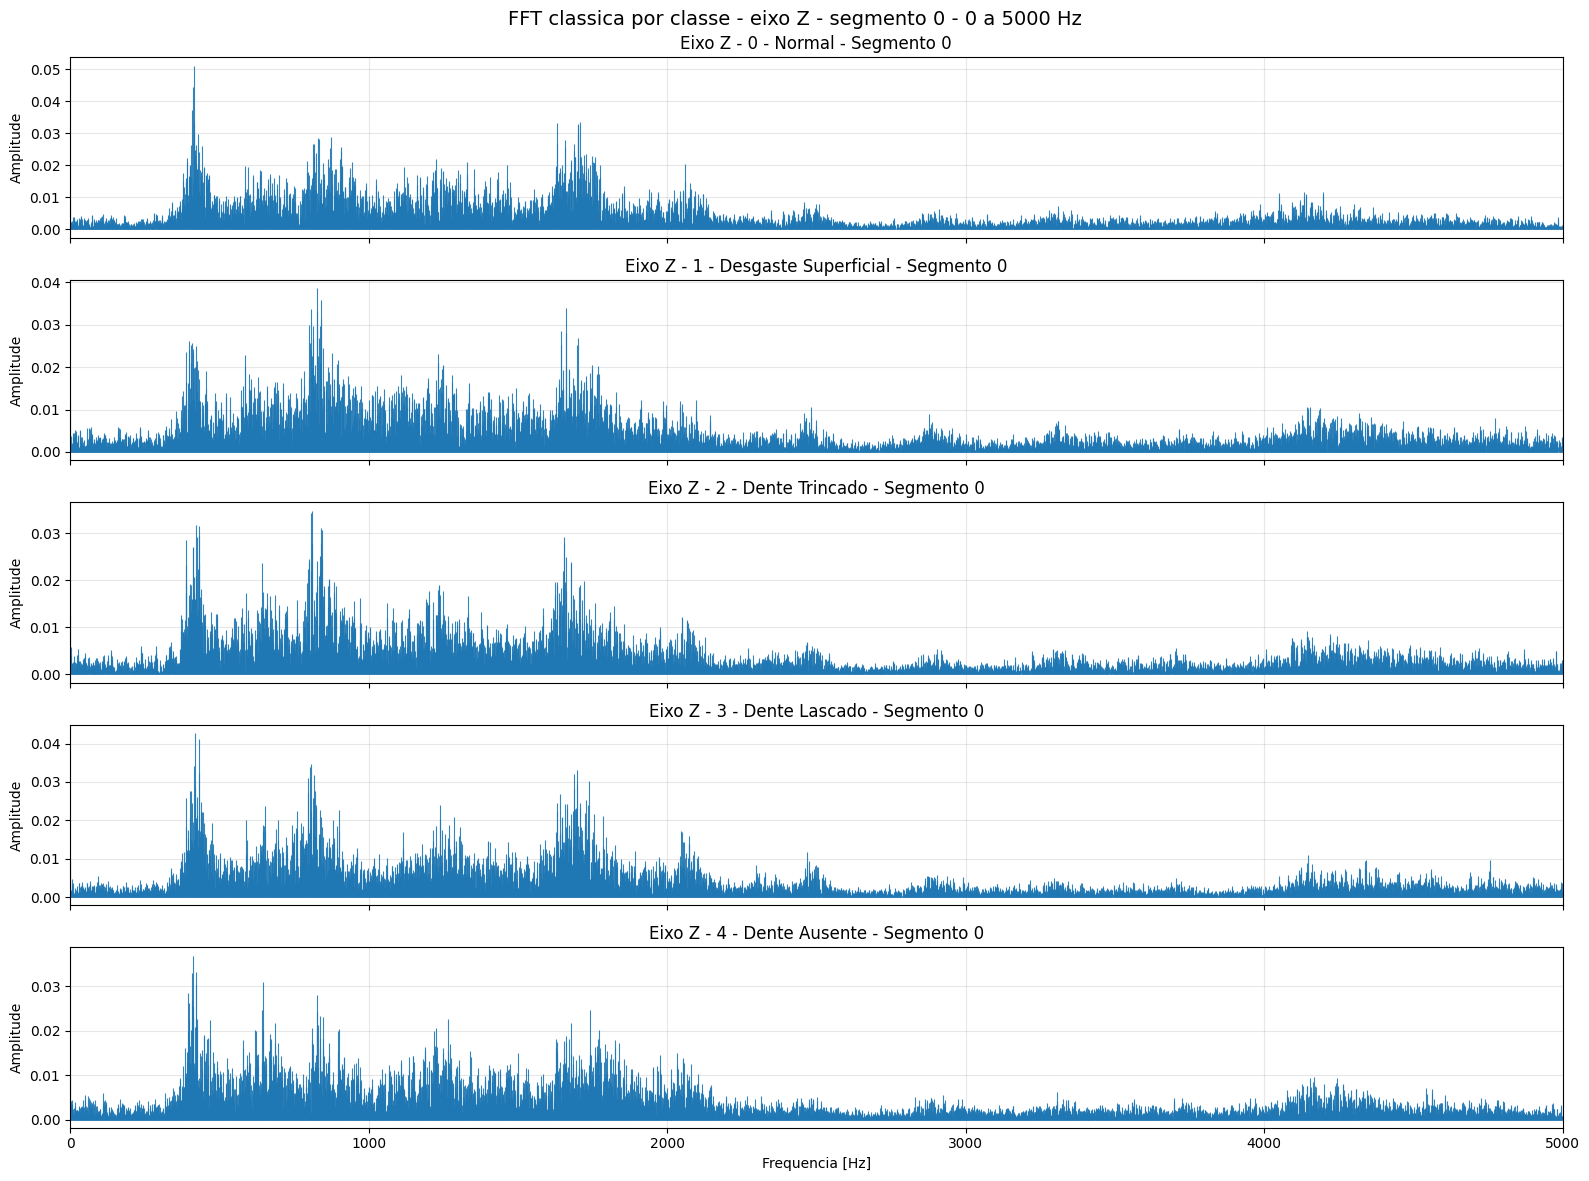

,classe,segmento,frequencia_pico_hz,amplitude_pico
0,0,0,416.0,0.051148
1,1,0,828.0,0.038670
2,2,0,812.0,0.034874
3,3,0,418.0,0.042740
4,4,0,412.0,0.036939


In [174]:
eixo_fft_plot = "z"
segmento_fft_plot = 0
frequencia_min_hz = 0
frequencia_max_hz = 5000
cor_fft = "tab:blue"

tempo_intervalo = np.arange(amostras_por_intervalo) / fs

segmentos_classes_eixo = {
    "x": [segmentos_eixo_x_classe0, segmentos_eixo_x_classe1, segmentos_eixo_x_classe2, segmentos_eixo_x_classe3, segmentos_eixo_x_classe4],
    "y": [segmentos_eixo_y_classe0, segmentos_eixo_y_classe1, segmentos_eixo_y_classe2, segmentos_eixo_y_classe3, segmentos_eixo_y_classe4],
    "z": [segmentos_eixo_z_classe0, segmentos_eixo_z_classe1, segmentos_eixo_z_classe2, segmentos_eixo_z_classe3, segmentos_eixo_z_classe4],
}

fft_por_classe = {}
picos_fft_segmento = []

for classe, segmentos_classe in enumerate(segmentos_classes_eixo[eixo_fft_plot]):
    if segmento_fft_plot >= segmentos_classe.shape[0]:
        raise ValueError(f"O segmento {segmento_fft_plot} nao existe para a classe {classe}.")

    df_fft_entrada = pd.DataFrame({
        "Tempo": tempo_intervalo,
        "Segmento": segmentos_classe[segmento_fft_plot],
    })

    fft_classe = FFT_multicanal(
        df_fft_entrada,
        time_col="Tempo",
        value_cols="Segmento",
        aplicar_janela=True,
        janela="hann",
        remover_dc=True,
    )

    fft_classe = fft_classe.rename(columns={"Amplitude_Segmento": "Amplitude_para_plot"})
    fft_por_classe[classe] = fft_classe[["Frequencia", "Amplitude_para_plot"]].copy()

    mascara_faixa = (fft_classe["Frequencia"] >= frequencia_min_hz) & (fft_classe["Frequencia"] <= frequencia_max_hz)
    fft_faixa = fft_classe.loc[mascara_faixa].copy()

    indice_pico = fft_faixa["Amplitude_para_plot"].idxmax()
    picos_fft_segmento.append({
        "classe": classe,
        "segmento": segmento_fft_plot,
        "frequencia_pico_hz": fft_classe.loc[indice_pico, "Frequencia"],
        "amplitude_pico": fft_classe.loc[indice_pico, "Amplitude_para_plot"],
    })

fig, axes = plt.subplots(5, 1, figsize=(16, 12), sharex=True)

for classe, ax in enumerate(axes):
    fft_classe = fft_por_classe[classe]
    mascara_freq = (fft_classe["Frequencia"] >= frequencia_min_hz) & (fft_classe["Frequencia"] <= frequencia_max_hz)
    frequencias_plot = fft_classe.loc[mascara_freq, "Frequencia"].to_numpy()
    amplitudes_plot = fft_classe.loc[mascara_freq, "Amplitude_para_plot"].to_numpy()

    marcador, hastes, base = ax.stem(frequencias_plot, amplitudes_plot, linefmt=cor_fft, markerfmt=" ", basefmt=" ")
    plt.setp(hastes, linewidth=0.8, alpha=0.9)
    ax.set_title(f"Eixo {eixo_fft_plot.upper()} - {rotulo_classe(classe)} - Segmento {segmento_fft_plot}")
    ax.set_ylabel("Amplitude")
    ax.set_xlim(frequencia_min_hz, frequencia_max_hz)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Frequencia [Hz]")
fig.suptitle(f"FFT classica por classe - eixo {eixo_fft_plot.upper()} - segmento {segmento_fft_plot} - {frequencia_min_hz} a {frequencia_max_hz} Hz", fontsize=14)

pasta_imagens = Path("images")
pasta_imagens.mkdir(exist_ok=True)
caminho_imagem_fft = pasta_imagens / f"fft_classica_sem_media_eixo_{eixo_fft_plot}_segmento_{segmento_fft_plot}_{int(frequencia_min_hz)}_{int(frequencia_max_hz)}Hz.png"
fig.savefig(caminho_imagem_fft, dpi=300, bbox_inches="tight")
print(f"Grafico salvo em: {caminho_imagem_fft}")

plt.tight_layout()
plt.show()

picos_fft_segmento = pd.DataFrame(picos_fft_segmento)
picos_fft_segmento


$$f_m = f_H \cdot z_r = \frac{z_r \cdot z_s}{z_r + z_s} \cdot f_{sh}$$

Onde:
- $f_m$: Frequência normal de engrenamento.  
- $f_H$: Frequência de rotação do suporte das engrenagens planetárias (planet carrier).  
- $z_r$: Número de dentes da engrenagem anelar (ring gear).  
- $z_s$: Número de dentes da engrenagem solar (sun gear).  
- $f_{sh}$: Frequência de rotação do eixo da engrenagem solar (velocidade de entrada). 

In [175]:
rotacao_entrada_rpm = 1500.0
Zr1 = 100.0
Zs1 = 20.0

Fsh1 = rotacao_entrada_rpm/60.0
Fm1 = ((Zr1 * Zs1)/(Zr1 + Zs1)) * Fsh1

In [176]:
rotacao_entrada_rpm = 1500.0
reducao_primeiro_estagio = 6.0
Zr2 = 100.0
Zs2 = 28.0

rotacao_entrada_segundo_estagio_reducao_planetaria = rotacao_entrada_rpm/reducao_primeiro_estagio
Fsh2 = rotacao_entrada_segundo_estagio_reducao_planetaria/60.0
Fm2 = ((Zr2 * Zs2)/(Zr2 + Zs2)) * Fsh2


Frequência de Falha Distribuída ($f_{csd}$)Esta fórmula é usada para calcular a frequência característica quando há um desgaste geral ou erro de manufatura distribuído na engrenagem solar 

$$f_{csd} = f_s^H = \frac{f_m}{z_s} = \frac{z_r}{z_r + z_s} \cdot f_{sh}$$

In [177]:
Fcsd1 = Fm1/Zs1

In [178]:
Fcsd2 = Fm2/Zs2

Frequência de Falha Local ($f_{csl}$)Esta fórmula é usada para calcular a frequência característica quando há um dano localizado, como um dente trincado ou quebrado, que irá colidir com as engrenagens planetárias a cada ciclo

$$f_{csl} = K \cdot f_s^H = K \cdot \frac{f_m}{z_s} = K \cdot \frac{z_r}{z_r + z_s} \cdot f_{sh}$$

In [179]:
Fcsl1 = 3 * Fcsd1

In [180]:
Fcsl2 = 4 * Fcsd2

In [181]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay, roc_curve, auc
from xgboost import XGBClassifier
import shap


In [182]:
Fm_teorico = Fm2
Fm1_teorico = Fm1
largura_busca_fm_real_hz = 10.0
largura_banda_harmonica_hz = 10.0
ordens_harmonicas_fm = list(range(1, 6))
ordens_harmonicas_fm1 = list(range(1, 6))
janela_hann = np.hanning(amostras_por_intervalo)
frequencias_fft = np.fft.rfftfreq(amostras_por_intervalo, d=1 / fs)

mascara_fm_real = (
    (frequencias_fft >= Fm_teorico - largura_busca_fm_real_hz)
    & (frequencias_fft <= Fm_teorico + largura_busca_fm_real_hz)
)

mascara_fm1_real = (
    (frequencias_fft >= Fm1_teorico - largura_busca_fm_real_hz)
    & (frequencias_fft <= Fm1_teorico + largura_busca_fm_real_hz)
)

mascara_ressonancia = (
    (frequencias_fft > 3000.0)
    & (frequencias_fft < 5000.0)
)

def calcular_espectro_amplitude(sinal_segmento, janela):
    sinal_centrado = sinal_segmento - np.mean(sinal_segmento)
    sinal_janelado = sinal_centrado * janela
    espectro = np.fft.rfft(sinal_janelado)
    amplitude = np.abs(espectro) * 2.0 / janela.sum()
    amplitude[0] = 0.0
    return amplitude

def extrair_pico_na_banda(amplitude_espectral, frequencias, mascara_banda):
    if not np.any(mascara_banda):
        return np.nan, np.nan

    amplitudes_banda = amplitude_espectral[mascara_banda]
    frequencias_banda = frequencias[mascara_banda]
    indice_pico = int(np.argmax(amplitudes_banda))
    return float(amplitudes_banda[indice_pico]), float(frequencias_banda[indice_pico])

def extrair_soma_amplitudes_na_banda(amplitude_espectral, mascara_banda):
    if not np.any(mascara_banda):
        return np.nan

    return float(np.sum(np.square(amplitude_espectral[mascara_banda])))

def extrair_amplitude_na_frequencia_alvo(amplitude_espectral, frequencias, frequencia_alvo):
    if np.isnan(frequencia_alvo):
        return np.nan

    indice_mais_proximo = int(np.argmin(np.abs(frequencias - frequencia_alvo)))
    return float(amplitude_espectral[indice_mais_proximo])

def calcular_rms(sinal_segmento):
    return float(np.sqrt(np.mean(np.square(sinal_segmento))))

def calcular_peak_value(sinal_segmento):
    return float(np.max(np.abs(sinal_segmento)))

def calcular_kurtosis(sinal_segmento):
    sinal_centrado = sinal_segmento - np.mean(sinal_segmento)
    desvio_padrao = np.std(sinal_centrado)
    if desvio_padrao == 0:
        return np.nan

    quarto_momento = np.mean(np.power(sinal_centrado, 4))
    return float(quarto_momento / np.power(desvio_padrao, 4))

def calcular_crest_factor(peak_value, rms):
    if rms == 0:
        return np.nan

    return float(peak_value / rms)

segmentos_classes_eixo = {
    "x": [segmentos_eixo_x_classe0, segmentos_eixo_x_classe1, segmentos_eixo_x_classe2, segmentos_eixo_x_classe3, segmentos_eixo_x_classe4],
    "y": [segmentos_eixo_y_classe0, segmentos_eixo_y_classe1, segmentos_eixo_y_classe2, segmentos_eixo_y_classe3, segmentos_eixo_y_classe4],
    "z": [segmentos_eixo_z_classe0, segmentos_eixo_z_classe1, segmentos_eixo_z_classe2, segmentos_eixo_z_classe3, segmentos_eixo_z_classe4],
}

features_modelo = []

for classe in range(5):
    quantidade_segmentos = segmentos_classes_eixo["x"][classe].shape[0]

    for segmento_id in range(quantidade_segmentos):
        linha = {
            "classe": classe,
            "segmento_id": segmento_id,
            "tempo_inicial_s": segmento_id * duracao_intervalo_s,
            "tempo_final_s": (segmento_id + 1) * duracao_intervalo_s,
        }

        for eixo, segmentos_por_classe in segmentos_classes_eixo.items():
            sinal_segmento = segmentos_por_classe[classe][segmento_id]
            rms = calcular_rms(sinal_segmento)
            peak_value = calcular_peak_value(sinal_segmento)
            kurtosis = calcular_kurtosis(sinal_segmento)
            linha[f"rms_{eixo}"] = rms
            linha[f"peak_value_{eixo}"] = peak_value
            linha[f"kurtosis_{eixo}"] = kurtosis
            linha[f"crest_factor_{eixo}"] = calcular_crest_factor(peak_value, rms)

            amplitude_espectral = calcular_espectro_amplitude(sinal_segmento, janela_hann)

            _, fm_real = extrair_pico_na_banda(
                amplitude_espectral,
                frequencias_fft,
                mascara_fm_real,
            )
            linha[f"fm_real_{eixo}"] = fm_real

            linha[f"amp_fcsd_esq_{eixo}"] = extrair_amplitude_na_frequencia_alvo(
                amplitude_espectral,
                frequencias_fft,
                fm_real - Fcsd2,
            )
            linha[f"amp_fcsd_dir_{eixo}"] = extrair_amplitude_na_frequencia_alvo(
                amplitude_espectral,
                frequencias_fft,
                fm_real + Fcsd2,
            )
            linha[f"amp_fcsl_esq_{eixo}"] = extrair_amplitude_na_frequencia_alvo(
                amplitude_espectral,
                frequencias_fft,
                fm_real - Fcsl2,
            )
            linha[f"amp_fcsl_dir_{eixo}"] = extrair_amplitude_na_frequencia_alvo(
                amplitude_espectral,
                frequencias_fft,
                fm_real + Fcsl2,
            )

            linha[f"energia_ressonancia_{eixo}"] = extrair_soma_amplitudes_na_banda(
                amplitude_espectral,
                mascara_ressonancia,
            )

            for ordem_harmonica in ordens_harmonicas_fm:
                frequencia_alvo = ordem_harmonica * fm_real
                mascara_harmonica = (
                    (frequencias_fft >= frequencia_alvo - largura_banda_harmonica_hz)
                    & (frequencias_fft <= frequencia_alvo + largura_banda_harmonica_hz)
                )
                amplitude_harmonica = extrair_soma_amplitudes_na_banda(
                    amplitude_espectral,
                    mascara_harmonica,
                )
                linha[f"amp_fm_h{ordem_harmonica}_{eixo}"] = amplitude_harmonica

            _, fm1_real = extrair_pico_na_banda(
                amplitude_espectral,
                frequencias_fft,
                mascara_fm1_real,
            )
            linha[f"fm1_real_{eixo}"] = fm1_real
            linha[f"amp_fcsd1_dir_{eixo}"] = extrair_amplitude_na_frequencia_alvo(
                amplitude_espectral,
                frequencias_fft,
                fm1_real + Fcsd1,
            )
            linha[f"amp_fcsl1_dir_{eixo}"] = extrair_amplitude_na_frequencia_alvo(
                amplitude_espectral,
                frequencias_fft,
                fm1_real + Fcsl1,
            )

            for ordem_harmonica in ordens_harmonicas_fm1:
                frequencia_alvo_fm1 = ordem_harmonica * fm1_real
                mascara_harmonica_fm1 = (
                    (frequencias_fft >= frequencia_alvo_fm1 - largura_banda_harmonica_hz)
                    & (frequencias_fft <= frequencia_alvo_fm1 + largura_banda_harmonica_hz)
                )
                amplitude_harmonica_fm1 = extrair_soma_amplitudes_na_banda(
                    amplitude_espectral,
                    mascara_harmonica_fm1,
                )
                linha[f"amp_fm1_h{ordem_harmonica}_{eixo}"] = amplitude_harmonica_fm1

        features_modelo.append(linha)

features_modelo = pd.DataFrame(features_modelo)

colunas_identificacao = ["classe", "segmento_id", "tempo_inicial_s", "tempo_final_s"]
colunas_features = [coluna for coluna in features_modelo.columns if coluna not in colunas_identificacao]

X_features = features_modelo[colunas_features].copy()
y_features = features_modelo["classe"].copy()

print(f"Fm1 teorico utilizada: {Fm1_teorico:.4f} Hz")
print(f"Fm2 teorico utilizada: {Fm_teorico:.4f} Hz")
print(f"Ordens harmonicas do 2o estagio: {ordens_harmonicas_fm}")
print(f"Ordens harmonicas do 1o estagio: {ordens_harmonicas_fm1}")
print(f"Janela para localizar Fm_real: +/- {largura_busca_fm_real_hz:.1f} Hz")
print(f"Janela para cada harmonica real: +/- {largura_banda_harmonica_hz:.1f} Hz")
print(f"Tamanho de X_features: {X_features.shape}")
features_modelo.head()


Fm1 teorico utilizada: 416.6667 Hz
Fm2 teorico utilizada: 91.1458 Hz
Ordens harmonicas do 2o estagio: [1, 2, 3, 4, 5]
Ordens harmonicas do 1o estagio: [1, 2, 3, 4, 5]
Janela para localizar Fm_real: +/- 10.0 Hz
Janela para cada harmonica real: +/- 10.0 Hz
Tamanho de X_features: (1000, 69)


,classe,segmento_id,tempo_inicial_s,tempo_final_s,rms_x,peak_value_x,kurtosis_x,crest_factor_x,fm_real_x,amp_fcsd_esq_x,...,amp_fm_h4_z,amp_fm_h5_z,fm1_real_z,amp_fcsd1_dir_z,amp_fcsl1_dir_z,amp_fm1_h1_z,amp_fm1_h2_z,amp_fm1_h3_z,amp_fm1_h4_z,amp_fm1_h5_z
0,0,0,0.0,1.0,0.093619,0.404441,3.096266,4.320080,97.0,0.002076,...,0.000495,0.005556,416.0,0.018672,0.001247,0.012601,0.003816,0.002763,0.003938,0.001289
1,0,1,1.0,2.0,0.092136,0.376662,3.064614,4.088110,86.0,0.001009,...,0.000419,0.005447,416.0,0.016812,0.007375,0.014745,0.003674,0.004577,0.006790,0.001590
2,0,2,2.0,3.0,0.092540,0.439837,3.083805,4.752937,82.0,0.002382,...,0.006669,0.001992,415.0,0.036854,0.012540,0.004880,0.004518,0.002303,0.004474,0.001858
3,0,3,3.0,4.0,0.094165,0.367715,3.093959,3.905021,82.0,0.001823,...,0.005653,0.001327,413.0,0.013608,0.004627,0.006851,0.003141,0.002489,0.005438,0.001089
4,0,4,4.0,5.0,0.093166,0.413657,3.118125,4.440009,86.0,0.003356,...,0.000482,0.009091,424.0,0.009191,0.002469,0.009822,0.005950,0.001068,0.004915,0.000384


## Descrição das features atuais do modelo

As features abaixo são calculadas por segmento e por eixo `x`, `y` e `z`.

**Domínio do tempo**
- `rms_*`: nível eficaz de vibração do segmento.
- `peak_value_*`: maior valor absoluto do sinal no segmento.
- `kurtosis_*`: mede impulsividade e concentração de picos no sinal.
- `crest_factor_*`: razão entre pico absoluto e RMS.

**Engrenamento normal do 2º estágio**
- `fm_real_*`: frequência real de engrenamento localizada em torno de `Fm2`.
- `amp_fm_h1_*` até `amp_fm_h5_*`: soma das amplitudes ao quadrado na banda em torno de cada harmônica de `fm_real`.
- `amp_fcsd_esq_*` e `amp_fcsd_dir_*`: amplitudes nas bandas laterais associadas à frequência de falha distribuída `Fcsd2`.
- `amp_fcsl_esq_*` e `amp_fcsl_dir_*`: amplitudes nas bandas laterais associadas à frequência de falha local `Fcsl2`.

**Controle do 1º estágio**
- `fm1_real_*`: frequência real de engrenamento localizada em torno de `Fm1`.
- `amp_fm1_h1_*` até `amp_fm1_h5_*`: soma das amplitudes ao quadrado na banda em torno das harmônicas do 1º estágio.
- `amp_fcsd1_dir_*` e `amp_fcsl1_dir_*`: amplitudes em frequências laterais do 1º estágio.

**Alta frequência**
- `energia_ressonancia_*`: soma das amplitudes ao quadrado da FFT entre `2000` e `5000 Hz`.

**Observação**
Apesar do prefixo `amp_`, as features harmônicas `amp_fm_*` e `amp_fm1_*` representam intensidade espectral por banda, calculada como soma de `amplitude^2`, e não apenas o pico máximo de um único bin.


In [183]:
amostras_explicacao_por_classe = 3

indices_explicacao = (
    features_modelo.groupby("classe", group_keys=False)
    .sample(n=amostras_explicacao_por_classe, random_state=42)
    .index
    .sort_values()
)

amostras_explicacao_info = features_modelo.loc[indices_explicacao, colunas_identificacao].copy()
amostras_explicacao_info = amostras_explicacao_info.reset_index().rename(columns={"index": "indice_original"})
amostras_explicacao_info["classe_nome"] = amostras_explicacao_info["classe"].map(mapa_classes)
amostras_explicacao_info = amostras_explicacao_info.sort_values(["classe", "segmento_id"]).reset_index(drop=True)
indices_explicacao_ordenados = amostras_explicacao_info["indice_original"].to_list()

X_explicacao = X_features.loc[indices_explicacao_ordenados].copy().reset_index(drop=True)
y_explicacao = y_features.loc[indices_explicacao_ordenados].copy().reset_index(drop=True)

X_restante = X_features.drop(index=indices_explicacao_ordenados)
y_restante = y_features.drop(index=indices_explicacao_ordenados)

X_train, X_test, y_train, y_test = train_test_split(
    X_restante,
    y_restante,
    test_size=0.3,
    random_state=42,
    stratify=y_restante,
)

classes_roc = np.array([0, 1, 2, 3, 4])
y_test_bin = label_binarize(y_test, classes=classes_roc)

random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=1,
)
random_forest.fit(X_train, y_train)
y_pred_rf = random_forest.predict(X_test)
y_proba_rf = random_forest.predict_proba(X_test)

xgboost_model = XGBClassifier(
    objective="multi:softprob",
    num_class=5,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=1,
)
xgboost_model.fit(X_train, y_train)
y_pred_xgb = xgboost_model.predict(X_test)
y_proba_xgb = xgboost_model.predict_proba(X_test)

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(C=10, kernel="rbf", gamma="scale", probability=True, random_state=42)),
])
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
y_proba_svm = svm_model.predict_proba(X_test)

metricas_random_forest = pd.DataFrame([{
    "modelo": "RandomForest",
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "precision_macro": precision_score(y_test, y_pred_rf, average="macro"),
    "recall_macro": recall_score(y_test, y_pred_rf, average="macro"),
    "f1_macro": f1_score(y_test, y_pred_rf, average="macro"),
}])

metricas_xgboost = pd.DataFrame([{
    "modelo": "XGBoost",
    "accuracy": accuracy_score(y_test, y_pred_xgb),
    "precision_macro": precision_score(y_test, y_pred_xgb, average="macro"),
    "recall_macro": recall_score(y_test, y_pred_xgb, average="macro"),
    "f1_macro": f1_score(y_test, y_pred_xgb, average="macro"),
}])

metricas_svm = pd.DataFrame([{
    "modelo": "SVM",
    "accuracy": accuracy_score(y_test, y_pred_svm),
    "precision_macro": precision_score(y_test, y_pred_svm, average="macro"),
    "recall_macro": recall_score(y_test, y_pred_svm, average="macro"),
    "f1_macro": f1_score(y_test, y_pred_svm, average="macro"),
}])

comparacao_modelos = pd.concat([metricas_random_forest, metricas_xgboost, metricas_svm], ignore_index=True)

print("Amostras reservadas para explicabilidade:")
print(amostras_explicacao_info.to_string(index=False))
print()
print(f"Tamanho treino: {X_train.shape}")
print(f"Tamanho teste: {X_test.shape}")
print(f"Tamanho explicacao: {X_explicacao.shape}")
comparacao_modelos


Amostras reservadas para explicabilidade:
 indice_original  classe  segmento_id  tempo_inicial_s  tempo_final_s          classe_nome
              15       0           15             15.0           16.0               Normal
              30       0           30             30.0           31.0               Normal
              95       0           95             95.0           96.0               Normal
             233       1           33             33.0           34.0 Desgaste Superficial
             321       1          121            121.0          122.0 Desgaste Superficial
             376       1          176            176.0          177.0 Desgaste Superficial
             414       2           14             14.0           15.0       Dente Trincado
             509       2          109            109.0          110.0       Dente Trincado
             560       2          160            160.0          161.0       Dente Trincado
             663       3           63           

,modelo,accuracy,precision_macro,recall_macro,f1_macro
0,RandomForest,0.972973,0.972862,0.972881,0.972789
1,XGBoost,0.962838,0.962983,0.962712,0.962708
2,SVM,0.986486,0.986441,0.986441,0.986441


Metricas - RandomForest
      modelo  accuracy  precision_macro  recall_macro  f1_macro
RandomForest  0.972973         0.972862      0.972881  0.972789
                      precision    recall  f1-score   support

              Normal       1.00      1.00      1.00        59
Desgaste Superficial       1.00      1.00      1.00        59
      Dente Trincado       0.93      0.95      0.94        59
       Dente Lascado       0.98      1.00      0.99        60
       Dente Ausente       0.95      0.92      0.93        59

            accuracy                           0.97       296
           macro avg       0.97      0.97      0.97       296
        weighted avg       0.97      0.97      0.97       296

Grafico salvo em: images\avaliacao_randomforest.png


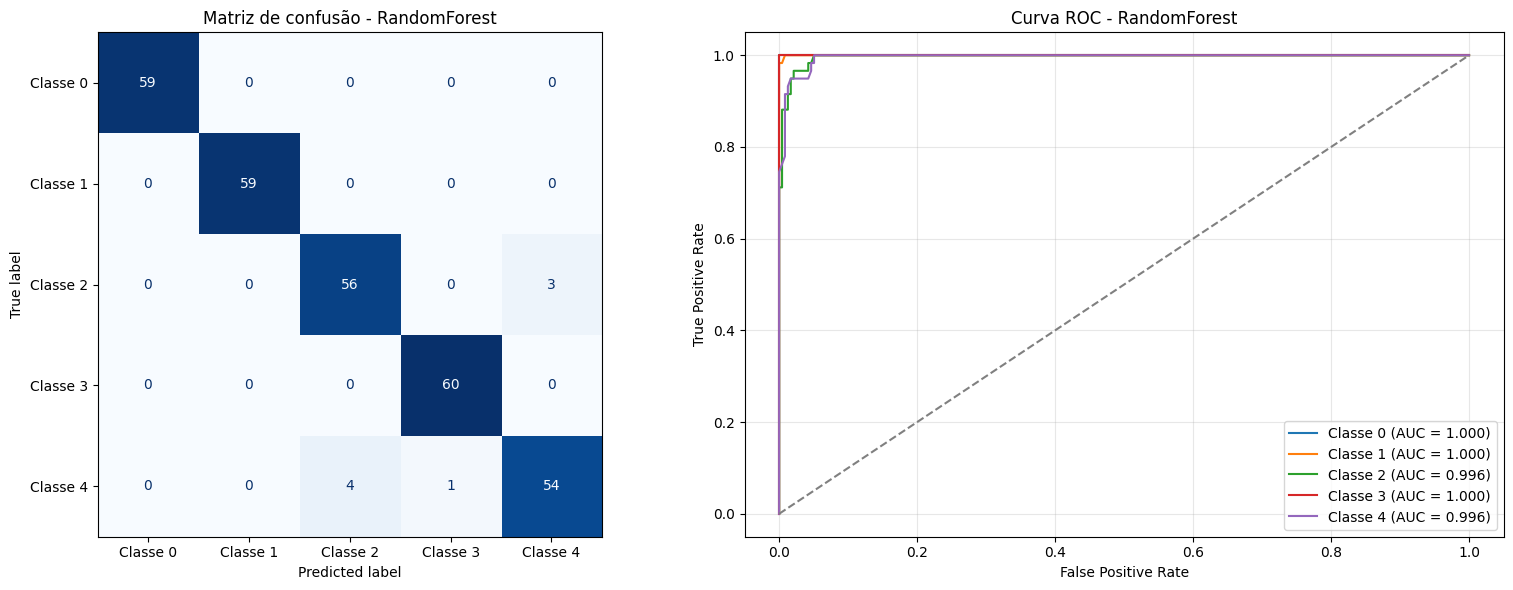

In [184]:
print("Metricas - RandomForest")
print(metricas_random_forest.to_string(index=False))
print(classification_report(y_test, y_pred_rf, labels=sorted(mapa_classes), target_names=nomes_classes_ordenados))

fpr_rf_0, tpr_rf_0, _ = roc_curve(y_test_bin[:, 0], y_proba_rf[:, 0])
fpr_rf_1, tpr_rf_1, _ = roc_curve(y_test_bin[:, 1], y_proba_rf[:, 1])
fpr_rf_2, tpr_rf_2, _ = roc_curve(y_test_bin[:, 2], y_proba_rf[:, 2])
fpr_rf_3, tpr_rf_3, _ = roc_curve(y_test_bin[:, 3], y_proba_rf[:, 3])
fpr_rf_4, tpr_rf_4, _ = roc_curve(y_test_bin[:, 4], y_proba_rf[:, 4])

auc_rf_0 = auc(fpr_rf_0, tpr_rf_0)
auc_rf_1 = auc(fpr_rf_1, tpr_rf_1)
auc_rf_2 = auc(fpr_rf_2, tpr_rf_2)
auc_rf_3 = auc(fpr_rf_3, tpr_rf_3)
auc_rf_4 = auc(fpr_rf_4, tpr_rf_4)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[0], cmap="Blues", colorbar=False, display_labels=labels_classes_curtas)
axes[0].set_title("Matriz de confusão - RandomForest")

axes[1].plot(fpr_rf_0, tpr_rf_0, linewidth=1.5, label=f"Classe 0 (AUC = {auc_rf_0:.3f})")
axes[1].plot(fpr_rf_1, tpr_rf_1, linewidth=1.5, label=f"Classe 1 (AUC = {auc_rf_1:.3f})")
axes[1].plot(fpr_rf_2, tpr_rf_2, linewidth=1.5, label=f"Classe 2 (AUC = {auc_rf_2:.3f})")
axes[1].plot(fpr_rf_3, tpr_rf_3, linewidth=1.5, label=f"Classe 3 (AUC = {auc_rf_3:.3f})")
axes[1].plot(fpr_rf_4, tpr_rf_4, linewidth=1.5, label=f"Classe 4 (AUC = {auc_rf_4:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("Curva ROC - RandomForest")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
pasta_imagens = Path("images")
pasta_imagens.mkdir(exist_ok=True)
caminho_random_forest = pasta_imagens / "avaliacao_randomforest.png"
fig.savefig(caminho_random_forest, dpi=300, bbox_inches="tight")
print(f"Grafico salvo em: {caminho_random_forest}")
plt.show()


Metricas - XGBoost
 modelo  accuracy  precision_macro  recall_macro  f1_macro
XGBoost  0.962838         0.962983      0.962712  0.962708
                      precision    recall  f1-score   support

              Normal       1.00      0.97      0.98        59
Desgaste Superficial       0.97      1.00      0.98        59
      Dente Trincado       0.92      0.93      0.92        59
       Dente Lascado       1.00      1.00      1.00        60
       Dente Ausente       0.93      0.92      0.92        59

            accuracy                           0.96       296
           macro avg       0.96      0.96      0.96       296
        weighted avg       0.96      0.96      0.96       296

Grafico salvo em: images\avaliacao_xgboost.png


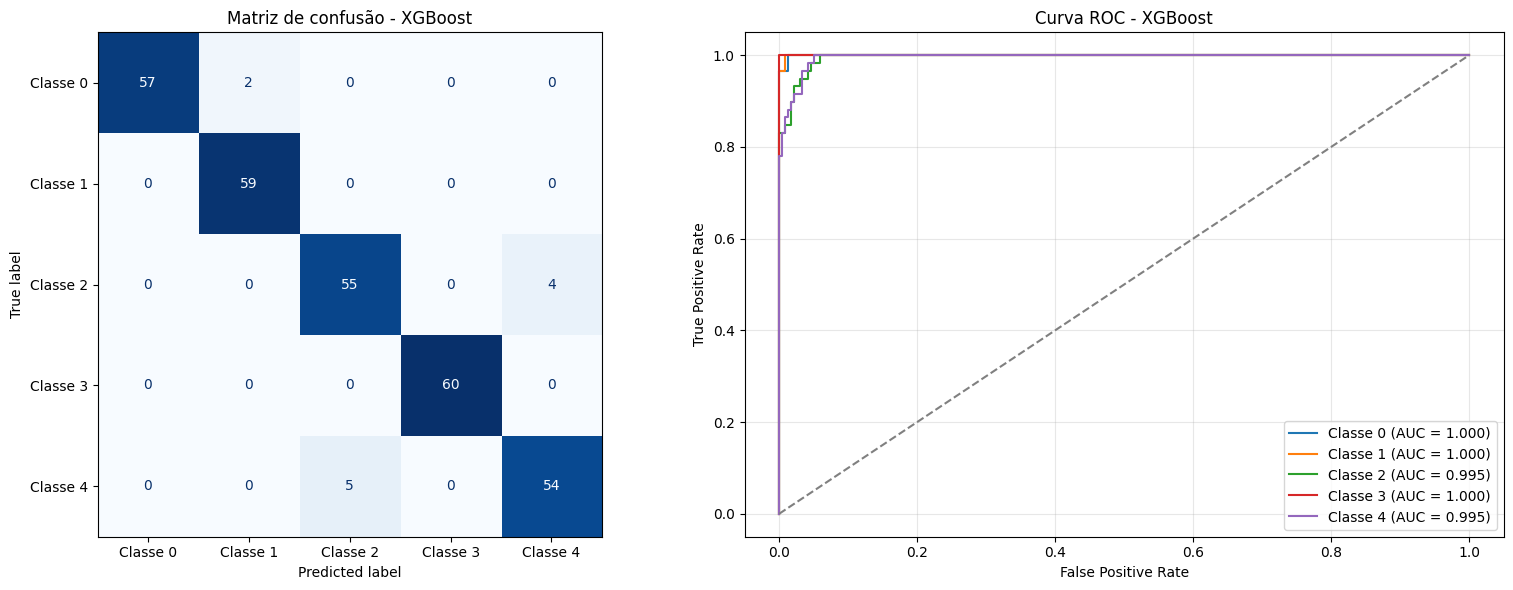

In [185]:
print("Metricas - XGBoost")
print(metricas_xgboost.to_string(index=False))
print(classification_report(y_test, y_pred_xgb, labels=sorted(mapa_classes), target_names=nomes_classes_ordenados))

fpr_xgb_0, tpr_xgb_0, _ = roc_curve(y_test_bin[:, 0], y_proba_xgb[:, 0])
fpr_xgb_1, tpr_xgb_1, _ = roc_curve(y_test_bin[:, 1], y_proba_xgb[:, 1])
fpr_xgb_2, tpr_xgb_2, _ = roc_curve(y_test_bin[:, 2], y_proba_xgb[:, 2])
fpr_xgb_3, tpr_xgb_3, _ = roc_curve(y_test_bin[:, 3], y_proba_xgb[:, 3])
fpr_xgb_4, tpr_xgb_4, _ = roc_curve(y_test_bin[:, 4], y_proba_xgb[:, 4])

auc_xgb_0 = auc(fpr_xgb_0, tpr_xgb_0)
auc_xgb_1 = auc(fpr_xgb_1, tpr_xgb_1)
auc_xgb_2 = auc(fpr_xgb_2, tpr_xgb_2)
auc_xgb_3 = auc(fpr_xgb_3, tpr_xgb_3)
auc_xgb_4 = auc(fpr_xgb_4, tpr_xgb_4)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, ax=axes[0], cmap="Blues", colorbar=False, display_labels=labels_classes_curtas)
axes[0].set_title("Matriz de confusão - XGBoost")

axes[1].plot(fpr_xgb_0, tpr_xgb_0, linewidth=1.5, label=f"Classe 0 (AUC = {auc_xgb_0:.3f})")
axes[1].plot(fpr_xgb_1, tpr_xgb_1, linewidth=1.5, label=f"Classe 1 (AUC = {auc_xgb_1:.3f})")
axes[1].plot(fpr_xgb_2, tpr_xgb_2, linewidth=1.5, label=f"Classe 2 (AUC = {auc_xgb_2:.3f})")
axes[1].plot(fpr_xgb_3, tpr_xgb_3, linewidth=1.5, label=f"Classe 3 (AUC = {auc_xgb_3:.3f})")
axes[1].plot(fpr_xgb_4, tpr_xgb_4, linewidth=1.5, label=f"Classe 4 (AUC = {auc_xgb_4:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("Curva ROC - XGBoost")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
pasta_imagens = Path("images")
pasta_imagens.mkdir(exist_ok=True)
caminho_xgboost = pasta_imagens / "avaliacao_xgboost.png"
fig.savefig(caminho_xgboost, dpi=300, bbox_inches="tight")
print(f"Grafico salvo em: {caminho_xgboost}")
plt.show()


Metricas - SVM
modelo  accuracy  precision_macro  recall_macro  f1_macro
   SVM  0.986486         0.986441      0.986441  0.986441
                      precision    recall  f1-score   support

              Normal       1.00      1.00      1.00        59
Desgaste Superficial       1.00      1.00      1.00        59
      Dente Trincado       0.97      0.97      0.97        59
       Dente Lascado       1.00      1.00      1.00        60
       Dente Ausente       0.97      0.97      0.97        59

            accuracy                           0.99       296
           macro avg       0.99      0.99      0.99       296
        weighted avg       0.99      0.99      0.99       296

Grafico salvo em: images\avaliacao_svm.png


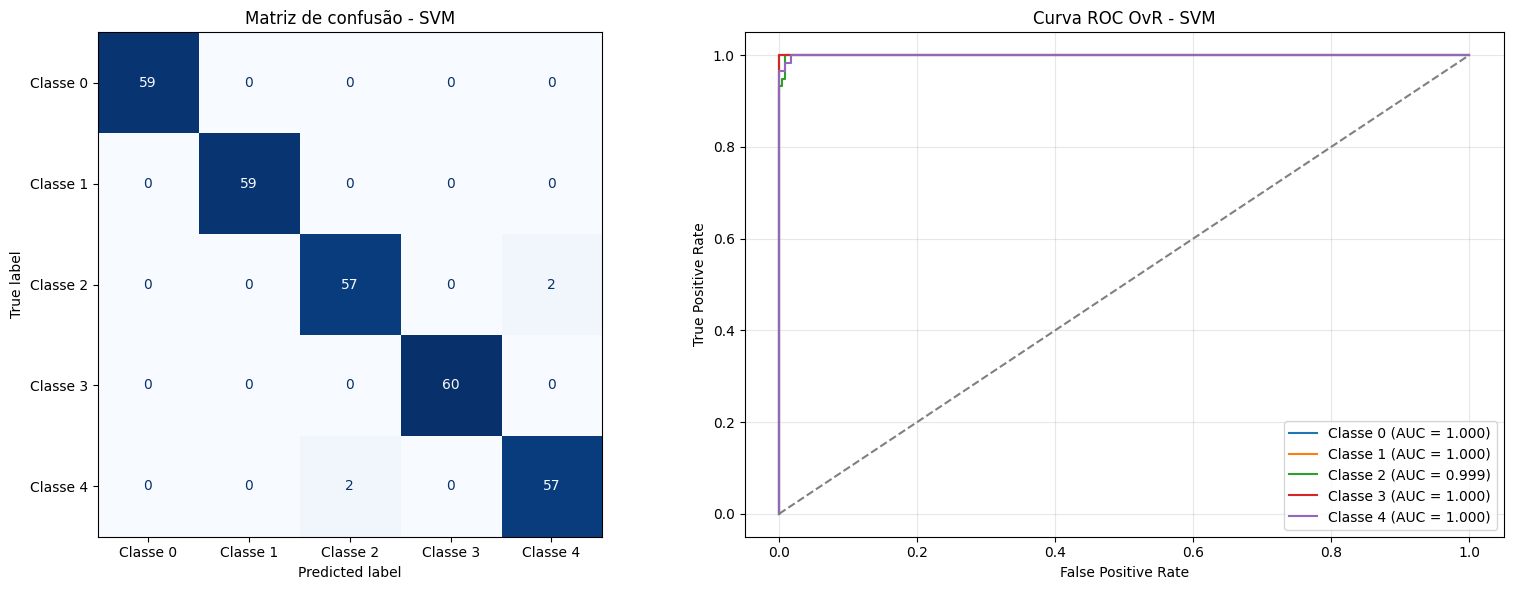

In [186]:
print("Metricas - SVM")
print(metricas_svm.to_string(index=False))
print(classification_report(y_test, y_pred_svm, labels=sorted(mapa_classes), target_names=nomes_classes_ordenados))

fpr_svm_0, tpr_svm_0, _ = roc_curve(y_test_bin[:, 0], y_proba_svm[:, 0])
fpr_svm_1, tpr_svm_1, _ = roc_curve(y_test_bin[:, 1], y_proba_svm[:, 1])
fpr_svm_2, tpr_svm_2, _ = roc_curve(y_test_bin[:, 2], y_proba_svm[:, 2])
fpr_svm_3, tpr_svm_3, _ = roc_curve(y_test_bin[:, 3], y_proba_svm[:, 3])
fpr_svm_4, tpr_svm_4, _ = roc_curve(y_test_bin[:, 4], y_proba_svm[:, 4])

auc_svm_0 = auc(fpr_svm_0, tpr_svm_0)
auc_svm_1 = auc(fpr_svm_1, tpr_svm_1)
auc_svm_2 = auc(fpr_svm_2, tpr_svm_2)
auc_svm_3 = auc(fpr_svm_3, tpr_svm_3)
auc_svm_4 = auc(fpr_svm_4, tpr_svm_4)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, ax=axes[0], cmap="Blues", colorbar=False, display_labels=labels_classes_curtas)
axes[0].set_title("Matriz de confusão - SVM")

axes[1].plot(fpr_svm_0, tpr_svm_0, linewidth=1.5, label=f"Classe 0 (AUC = {auc_svm_0:.3f})")
axes[1].plot(fpr_svm_1, tpr_svm_1, linewidth=1.5, label=f"Classe 1 (AUC = {auc_svm_1:.3f})")
axes[1].plot(fpr_svm_2, tpr_svm_2, linewidth=1.5, label=f"Classe 2 (AUC = {auc_svm_2:.3f})")
axes[1].plot(fpr_svm_3, tpr_svm_3, linewidth=1.5, label=f"Classe 3 (AUC = {auc_svm_3:.3f})")
axes[1].plot(fpr_svm_4, tpr_svm_4, linewidth=1.5, label=f"Classe 4 (AUC = {auc_svm_4:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("Curva ROC OvR - SVM")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
pasta_imagens = Path("images")
pasta_imagens.mkdir(exist_ok=True)
caminho_svm = pasta_imagens / "avaliacao_svm.png"
fig.savefig(caminho_svm, dpi=300, bbox_inches="tight")
print(f"Grafico salvo em: {caminho_svm}")
plt.show()


In [187]:
def organizar_shap_multiclasse(shap_values, n_classes):
    if hasattr(shap_values, "values"):
        shap_array = shap_values.values
    else:
        shap_array = shap_values

    if isinstance(shap_array, list):
        return np.stack(shap_array, axis=0)

    shap_array = np.asarray(shap_array)

    if shap_array.ndim == 3 and shap_array.shape[2] == n_classes:
        return np.moveaxis(shap_array, 2, 0)

    if shap_array.ndim == 3 and shap_array.shape[0] == n_classes:
        return shap_array

    raise ValueError(f"Formato de SHAP nao suportado: {shap_array.shape}")

def tabela_shap_local(modelo, X_ref, info_ref, nome_modelo, top_k=5):
    explainer = shap.TreeExplainer(modelo)
    shap_raw = explainer.shap_values(X_ref)
    shap_classes = organizar_shap_multiclasse(shap_raw, n_classes=len(classes_roc))
    predicoes = modelo.predict(X_ref)
    probabilidades = modelo.predict_proba(X_ref)

    linhas = []

    for i in range(X_ref.shape[0]):
        classe_predita = int(predicoes[i])
        valores_shap = shap_classes[classe_predita, i, :]
        ordem = np.argsort(np.abs(valores_shap))[::-1][:top_k]

        for posicao, indice_feature in enumerate(ordem, start=1):
            linhas.append({
                "modelo": nome_modelo,
                "amostra_explicacao": i,
                "classe_real": int(y_explicacao.iloc[i]),
                "classe_real_nome": mapa_classes[int(y_explicacao.iloc[i])],
                "classe_predita": classe_predita,
                "classe_predita_nome": mapa_classes[classe_predita],
                "probabilidade_predita": float(probabilidades[i, classe_predita]),
                "indice_original": int(info_ref.loc[i, "indice_original"]),
                "segmento_id": int(info_ref.loc[i, "segmento_id"]),
                "tempo_inicial_s": float(info_ref.loc[i, "tempo_inicial_s"]),
                "tempo_final_s": float(info_ref.loc[i, "tempo_final_s"]),
                "rank": posicao,
                "feature": X_ref.columns[indice_feature],
                "valor_feature": float(X_ref.iloc[i, indice_feature]),
                "shap_value": float(valores_shap[indice_feature]),
                "impacto_absoluto": float(abs(valores_shap[indice_feature])),
            })

    return pd.DataFrame(linhas)


Top features SHAP - RandomForest
      modelo  amostra_explicacao  classe_real     classe_real_nome  classe_predita  classe_predita_nome  probabilidade_predita  indice_original  segmento_id  tempo_inicial_s  tempo_final_s  rank               feature  valor_feature  shap_value  impacto_absoluto
RandomForest                   0            0               Normal               0               Normal               0.933333               15           15             15.0           16.0     1                 rms_x       0.093844    0.108208          0.108208
RandomForest                   0            0               Normal               0               Normal               0.933333               15           15             15.0           16.0     2 energia_ressonancia_x       0.001179    0.096976          0.096976
RandomForest                   0            0               Normal               0               Normal               0.933333               15           15             15.0        

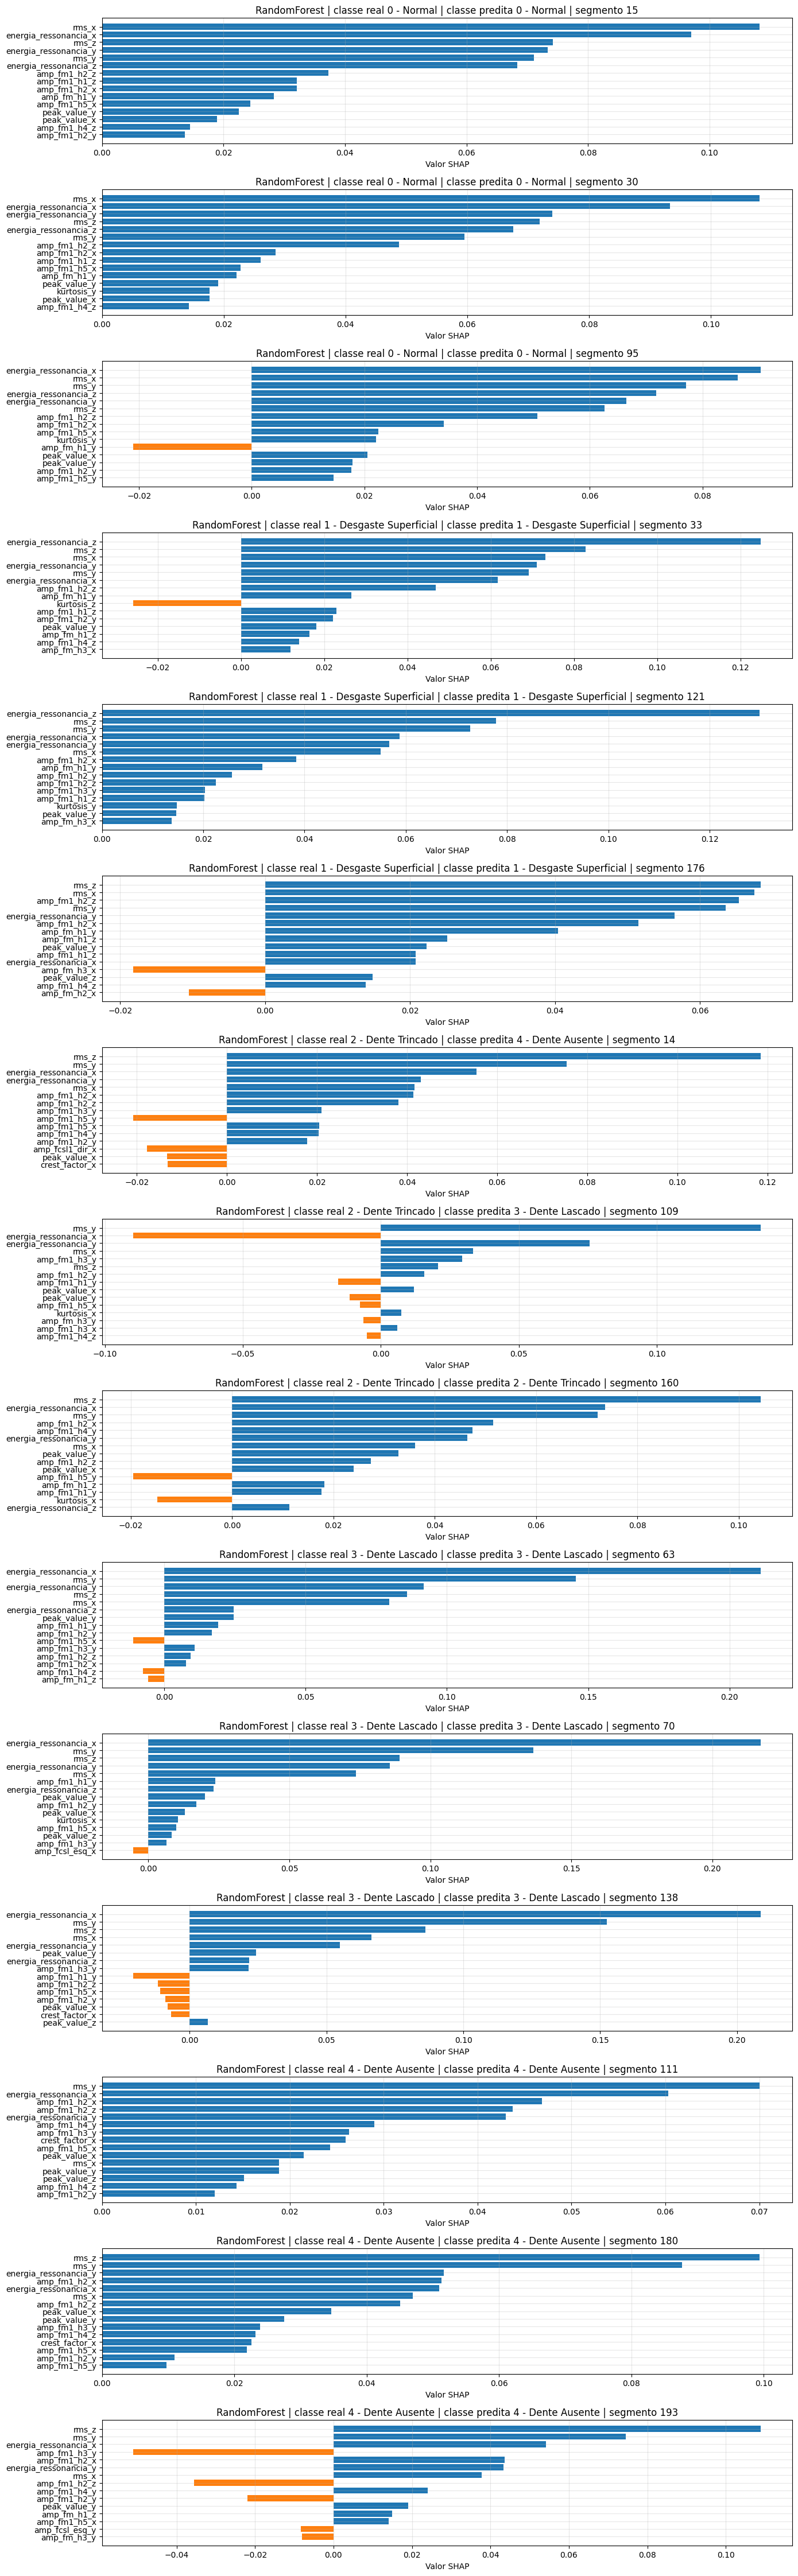

In [188]:
tabela_shap_rf = tabela_shap_local(random_forest, X_explicacao, amostras_explicacao_info, "RandomForest", top_k=15)
print("Top features SHAP - RandomForest")
print(tabela_shap_rf.to_string(index=False))

fig, axes = plt.subplots(X_explicacao.shape[0], 1, figsize=(14, 3 * X_explicacao.shape[0]), sharex=False)
if X_explicacao.shape[0] == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    tabela_amostra = tabela_shap_rf[tabela_shap_rf["amostra_explicacao"] == i].sort_values("impacto_absoluto", ascending=True)
    cores = ["tab:blue" if valor >= 0 else "tab:orange" for valor in tabela_amostra["shap_value"]]
    ax.barh(tabela_amostra["feature"], tabela_amostra["shap_value"], color=cores)
    classe_real = int(tabela_amostra["classe_real"].iloc[0])
    classe_predita = int(tabela_amostra["classe_predita"].iloc[0])
    segmento_id = int(tabela_amostra["segmento_id"].iloc[0])
    ax.set_title(f"RandomForest | classe real {rotulo_classe(classe_real)} | classe predita {rotulo_classe(classe_predita)} | segmento {segmento_id}")
    ax.set_xlabel("Valor SHAP")
    ax.grid(alpha=0.3)

plt.tight_layout()
pasta_imagens = Path("images")
pasta_imagens.mkdir(exist_ok=True)
caminho_shap_rf = pasta_imagens / "shap_local_randomforest.png"
fig.savefig(caminho_shap_rf, dpi=300, bbox_inches="tight")
print(f"Grafico salvo em: {caminho_shap_rf}")
plt.show()


Top features SHAP - XGBoost
 modelo  amostra_explicacao  classe_real     classe_real_nome  classe_predita  classe_predita_nome  probabilidade_predita  indice_original  segmento_id  tempo_inicial_s  tempo_final_s  rank               feature  valor_feature  shap_value  impacto_absoluto
XGBoost                   0            0               Normal               0               Normal               0.997833               15           15             15.0           16.0     1 energia_ressonancia_x       0.001179    2.416476          2.416476
XGBoost                   0            0               Normal               0               Normal               0.997833               15           15             15.0           16.0     2                 rms_x       0.093844    1.071182          1.071182
XGBoost                   0            0               Normal               0               Normal               0.997833               15           15             15.0           16.0     3 energia_res

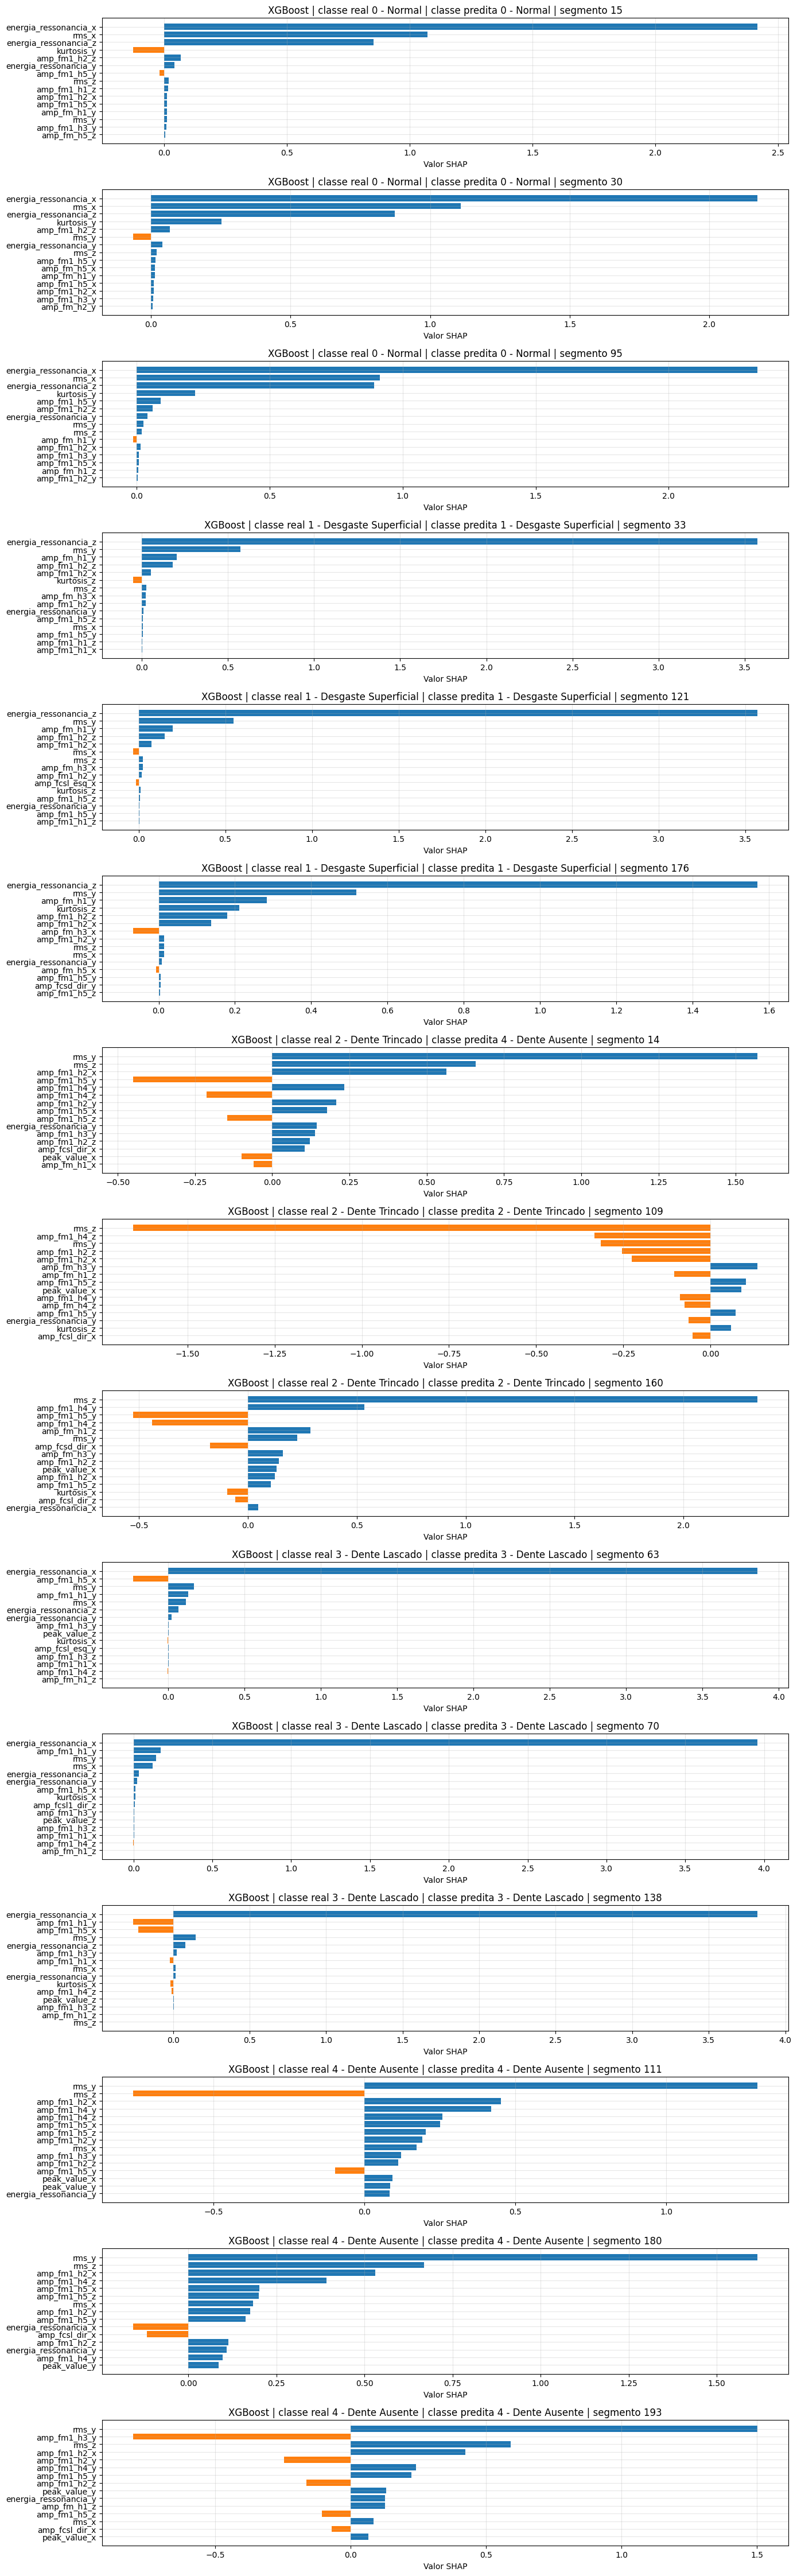

In [189]:
tabela_shap_xgb = tabela_shap_local(xgboost_model, X_explicacao, amostras_explicacao_info, "XGBoost", top_k=15)
print("Top features SHAP - XGBoost")
print(tabela_shap_xgb.to_string(index=False))

fig, axes = plt.subplots(X_explicacao.shape[0], 1, figsize=(14, 3 * X_explicacao.shape[0]), sharex=False)
if X_explicacao.shape[0] == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    tabela_amostra = tabela_shap_xgb[tabela_shap_xgb["amostra_explicacao"] == i].sort_values("impacto_absoluto", ascending=True)
    cores = ["tab:blue" if valor >= 0 else "tab:orange" for valor in tabela_amostra["shap_value"]]
    ax.barh(tabela_amostra["feature"], tabela_amostra["shap_value"], color=cores)
    classe_real = int(tabela_amostra["classe_real"].iloc[0])
    classe_predita = int(tabela_amostra["classe_predita"].iloc[0])
    segmento_id = int(tabela_amostra["segmento_id"].iloc[0])
    ax.set_title(f"XGBoost | classe real {rotulo_classe(classe_real)} | classe predita {rotulo_classe(classe_predita)} | segmento {segmento_id}")
    ax.set_xlabel("Valor SHAP")
    ax.grid(alpha=0.3)

plt.tight_layout()
pasta_imagens = Path("images")
pasta_imagens.mkdir(exist_ok=True)
caminho_shap_xgb = pasta_imagens / "shap_local_xgboost.png"
fig.savefig(caminho_shap_xgb, dpi=300, bbox_inches="tight")
print(f"Grafico salvo em: {caminho_shap_xgb}")
plt.show()


In [190]:
import re

def descrever_feature_tecnica(feature, valor_feature, shap_value):
    eixo_map = {"x": "X", "y": "Y", "z": "Z"}
    direcao = "increased" if shap_value >= 0 else "reduced"
    tendencia = "stronger evidence" if shap_value >= 0 else "weaker evidence"

    def ordinal_label(valor):
        mapa = {"1": "1st", "2": "2nd", "3": "3rd", "4": "4th", "5": "5th", "6": "6th", "7": "7th", "8": "8th", "9": "9th", "10": "10th", "11": "11th", "12": "12th"}
        return mapa.get(str(valor), f"{valor}th")

    match = re.match(r"rms_([xyz])$", feature)
    if match:
        eixo = match.group(1)
        return f"The RMS value on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, representing the effective vibration level of the segment."

    match = re.match(r"peak_value_([xyz])$", feature)
    if match:
        eixo = match.group(1)
        return f"The absolute peak value on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, indicating the intensity of the highest vibration excursion in the segment."

    match = re.match(r"kurtosis_([xyz])$", feature)
    if match:
        eixo = match.group(1)
        return f"The kurtosis on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, reflecting a more or less impulsive vibration pattern."

    match = re.match(r"crest_factor_([xyz])$", feature)
    if match:
        eixo = match.group(1)
        return f"The crest factor on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, indicating the relationship between transient peaks and the effective vibration level."

    match = re.match(r"fm_real_([xyz])$", feature)
    if match:
        eixo = match.group(1)
        return f"The detected real meshing frequency of the second stage on axis {eixo_map[eixo]} was {valor_feature:.2f} Hz and {direcao} the evidence for the predicted class, indicating a shift or concentration around the expected mesh component."

    match = re.match(r"amp_fm_h(\d+)_([xyz])$", feature)
    if match:
        harmonico, eixo = match.groups()
        ordinal = ordinal_label(harmonico)
        return f"The summed squared spectral amplitude within the band around the {ordinal} harmonic of the second-stage meshing frequency on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, reflecting the vibrational intensity concentrated near this harmonic."

    match = re.match(r"amp_fcsd_(esq|dir)_([xyz])$", feature)
    if match:
        lado, eixo = match.groups()
        side = "lower" if lado == "esq" else "upper"
        return f"The amplitude at the {side} sideband associated with the second-stage distributed fault frequency on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, indicating modulation around the normal meshing component."

    match = re.match(r"amp_fcsl_(esq|dir)_([xyz])$", feature)
    if match:
        lado, eixo = match.groups()
        side = "lower" if lado == "esq" else "upper"
        return f"The amplitude at the {side} sideband associated with the second-stage local fault frequency on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, suggesting local modulation effects near the mesh frequency."

    match = re.match(r"fm1_real_([xyz])$", feature)
    if match:
        eixo = match.group(1)
        return f"The detected real meshing frequency of the first stage on axis {eixo_map[eixo]} was {valor_feature:.2f} Hz and {direcao} the evidence for the predicted class, acting as a control indicator for first-stage spectral activity."

    match = re.match(r"amp_fm1_h(\d+)_([xyz])$", feature)
    if match:
        harmonico, eixo = match.groups()
        ordinal = ordinal_label(harmonico)
        return f"The summed squared spectral amplitude within the band around the {ordinal} harmonic of the first-stage meshing frequency on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, representing control information from the first-stage mesh response."

    match = re.match(r"amp_fcsd1_dir_([xyz])$", feature)
    if match:
        eixo = match.group(1)
        return f"The amplitude at the upper sideband associated with the first-stage distributed fault frequency on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, indicating modulation linked to the first-stage mesh."

    match = re.match(r"amp_fcsl1_dir_([xyz])$", feature)
    if match:
        eixo = match.group(1)
        return f"The amplitude at the upper sideband associated with the first-stage local fault frequency on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, indicating localized modulation linked to the first-stage mesh."

    match = re.match(r"energia_ressonancia_([xyz])$", feature)
    if match:
        eixo = match.group(1)
        return f"The summed squared spectral amplitude in the 2000 to 5000 Hz resonance band on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, reflecting high-frequency vibrational excitation and possible structural impact response."

    return f"Feature {feature} had a value of {valor_feature:.6f} and {direcao} the evidence for the predicted class, contributing to {tendencia} in the diagnostic decision."

def tabela_shap_texto_tecnico(tabela_shap):
    tabela_texto = tabela_shap.copy()
    tabela_texto["leitura_tecnica"] = tabela_texto.apply(
        lambda row: descrever_feature_tecnica(row["feature"], row["valor_feature"], row["shap_value"]),
        axis=1,
    )
    return tabela_texto

def resumo_tecnico_por_amostra(tabela_texto):
    resumos = []
    for amostra_id in sorted(tabela_texto["amostra_explicacao"].unique()):
        tabela_amostra = tabela_texto[tabela_texto["amostra_explicacao"] == amostra_id].sort_values("rank")
        classe_real = int(tabela_amostra["classe_real"].iloc[0])
        classe_real_nome = tabela_amostra["classe_real_nome"].iloc[0]
        classe_predita = int(tabela_amostra["classe_predita"].iloc[0])
        classe_predita_nome = tabela_amostra["classe_predita_nome"].iloc[0]
        probabilidade = float(tabela_amostra["probabilidade_predita"].iloc[0])
        segmento_id = int(tabela_amostra["segmento_id"].iloc[0])
        tempo_inicial = float(tabela_amostra["tempo_inicial_s"].iloc[0])
        tempo_final = float(tabela_amostra["tempo_final_s"].iloc[0])
        texto_base = " ".join(tabela_amostra["leitura_tecnica"].tolist())
        resumo = (
            f"Sample {amostra_id} | segment {segmento_id} | interval {tempo_inicial:.1f}-{tempo_final:.1f} s | "
            f"true class {classe_real} ({classe_real_nome}) | predicted class {classe_predita} ({classe_predita_nome}) | probability {probabilidade:.3f}. "
            + texto_base
        )
        resumos.append({
            "amostra_explicacao": amostra_id,
            "classe_real": classe_real,
            "classe_real_nome": classe_real_nome,
            "classe_predita": classe_predita,
            "classe_predita_nome": classe_predita_nome,
            "probabilidade_predita": probabilidade,
            "segmento_id": segmento_id,
            "tempo_inicial_s": tempo_inicial,
            "tempo_final_s": tempo_final,
            "resumo_tecnico": resumo,
        })
    return pd.DataFrame(resumos)


In [191]:
tabela_shap_rf_texto = tabela_shap_texto_tecnico(tabela_shap_rf)
resumo_shap_rf_texto = resumo_tecnico_por_amostra(tabela_shap_rf_texto)

print("SHAP table in technical English - RandomForest")
print(tabela_shap_rf_texto[["amostra_explicacao", "classe_real", "classe_predita", "rank", "feature", "shap_value", "leitura_tecnica"]].to_string(index=False))
print()
print("Technical summary by sample - RandomForest")
print(resumo_shap_rf_texto[["amostra_explicacao", "resumo_tecnico"]].to_string(index=False))


SHAP table in technical English - RandomForest
 amostra_explicacao  classe_real  classe_predita  rank               feature  shap_value                                                                                                                                                                                                                                                      leitura_tecnica
                  0            0               0     1                 rms_x    0.108208                                                                                                                  The RMS value on axis X was 0.093844 and increased the evidence for the predicted class, representing the effective vibration level of the segment.
                  0            0               0     2 energia_ressonancia_x    0.096976                     The summed squared spectral amplitude in the 2000 to 5000 Hz resonance band on axis X was 0.001179 and increased the evidence for the predicted 

In [192]:
tabela_shap_xgb_texto = tabela_shap_texto_tecnico(tabela_shap_xgb)
resumo_shap_xgb_texto = resumo_tecnico_por_amostra(tabela_shap_xgb_texto)

print("SHAP table in technical English - XGBoost")
print(tabela_shap_xgb_texto[["amostra_explicacao", "classe_real", "classe_predita", "rank", "feature", "shap_value", "leitura_tecnica"]].to_string(index=False))
print()
print("Technical summary by sample - XGBoost")
print(resumo_shap_xgb_texto[["amostra_explicacao", "resumo_tecnico"]].to_string(index=False))


SHAP table in technical English - XGBoost
 amostra_explicacao  classe_real  classe_predita  rank               feature  shap_value                                                                                                                                                                                                                                                      leitura_tecnica
                  0            0               0     1 energia_ressonancia_x    2.416476                     The summed squared spectral amplitude in the 2000 to 5000 Hz resonance band on axis X was 0.001179 and increased the evidence for the predicted class, reflecting high-frequency vibrational excitation and possible structural impact response.
                  0            0               0     2                 rms_x    1.071182                                                                                                                  The RMS value on axis X was 0.093844 and increased the e

In [193]:
import os
from openai import OpenAI

def carregar_openai_api_key():
    api_key = os.getenv("OPENAI_API_KEY")
    if api_key:
        return api_key

    caminho_env = Path(".env")
    if caminho_env.exists():
        conteudo_env = caminho_env.read_text(encoding="utf-8").strip()

        if conteudo_env.startswith("sk-"):
            return conteudo_env.strip().strip(chr(34)).strip(chr(39))

        for linha in conteudo_env.splitlines():
            linha = linha.strip()
            if not linha or linha.startswith("#") or "=" not in linha:
                continue
            chave, valor = linha.split("=", 1)
            if chave.strip() == "OPENAI_API_KEY":
                return valor.strip().strip(chr(34)).strip(chr(39))

    raise ValueError("OPENAI_API_KEY was not found in the environment or in the .env file.")

openai_api_key = carregar_openai_api_key()
openai_model = os.getenv("OPENAI_MODEL", "gpt-5-mini")
cliente_openai = OpenAI(api_key=openai_api_key)

print(f"OpenAI client configured with model: {openai_model}")
print("API key loaded successfully from environment or .env")


OpenAI client configured with model: gpt-5-mini
API key loaded successfully from environment or .env


In [227]:
fonte_shap_llm = "XGBoost"  # choose between "RandomForest" and "XGBoost"
gerar_explicacoes_llm = True
amostra_explicacao_llm = 14

if fonte_shap_llm == "RandomForest":
    tabela_shap_fonte_llm = tabela_shap_rf.copy()
elif fonte_shap_llm == "XGBoost":
    tabela_shap_fonte_llm = tabela_shap_xgb.copy()
else:
    raise ValueError("Invalid fonte_shap_llm. Use RandomForest or XGBoost.")

tabela_llm_amostra = tabela_shap_fonte_llm[
    tabela_shap_fonte_llm["amostra_explicacao"] == amostra_explicacao_llm
].sort_values("rank").copy()

if tabela_llm_amostra.empty:
    raise ValueError("A amostra selecionada para o LLM nao foi encontrada.")

row_llm = tabela_llm_amostra.iloc[0]

def traduzir_feature_para_llm(row):
    leitura = descrever_feature_tecnica(row["feature"], row["valor_feature"], row["shap_value"])
    efeito = "supports the predicted class" if row["shap_value"] >= 0 else "weakens the predicted class"
    return (
        f"{int(row['rank'])}. {leitura} "
        f"Diagnostic effect: {efeito}. "
        f"Absolute impact: {float(row['impacto_absoluto']):.6f}."
    )

top_features_traduzidas_llm = "\n".join(
    tabela_llm_amostra.apply(traduzir_feature_para_llm, axis=1).tolist()
)

legenda_fisica_variaveis_llm = """
Physical legend of variables:
- RMS: effective vibration level of the segment.
- peak_value: highest absolute vibration peak in the segment.
- kurtosis: impulsiveness indicator; higher values suggest more impulsive events.
- crest_factor: ratio between absolute peak and RMS; higher values suggest stronger transients.
- fm_real: detected real meshing frequency of the second stage.
- amp_fm_hN: summed squared spectral amplitude around the Nth harmonic of the second-stage meshing frequency.
- amp_fcsd_esq/dir: lower or upper sideband amplitude associated with the distributed fault frequency of the second stage.
- amp_fcsl_esq/dir: lower or upper sideband amplitude associated with the local fault frequency of the second stage.
- fm1_real: detected real meshing frequency of the first stage, used as a control reference.
- amp_fm1_hN: summed squared spectral amplitude around the Nth harmonic of the first-stage meshing frequency.
- amp_fcsd1_dir and amp_fcsl1_dir: first-stage sideband amplitudes used as control references.
- energia_ressonancia: summed squared spectral amplitude in the 2000 to 5000 Hz resonance band.
"""

instrucoes_llm = f"""
You are a predictive maintenance specialist for industrial rotating equipment.
Write the explanation in Brazilian Portuguese.
Use concise and technically precise maintenance language.
Do not mention SHAP, feature importance, AI, model internals, or prompt instructions.
Your response must contain exactly the following two section headers, in this exact order:
Interpretação Vibracional:
Interpretação Mecânica:
Do not add any other headers, bullet lists, or recommendation sections.
Base the explanation only on the predicted class, predicted probability, and translated evidence provided in the prompt.
Be direct and objective.
Do not invent causes, components, frequencies, inspection findings, or actions that are not supported by the provided evidence.
If the evidence is insufficient for a stronger conclusion, say that the indication is inconclusive or suggestive rather than certain.
Do not mention parts or subsystems unless they are justified by the predicted class or by the provided evidence.
In Interpretação Vibracional, explain the vibration evidence and indicate the most relevant axes and frequency components or bands.
In Interpretação Mecânica, describe the most likely mechanical interpretation and keep the statement proportional to the evidence.
Keep the full response concise, factual, and grounded in the evidence.
\n{legenda_fisica_variaveis_llm}
"""

def extrair_uso_tokens_openai(resposta):
    usage = getattr(resposta, "usage", None)

    if usage is None:
        return {
            "input_tokens": None,
            "cached_input_tokens": None,
            "output_tokens": None,
            "total_tokens": None,
        }

    input_tokens = int(getattr(usage, "input_tokens", 0) or 0)
    output_tokens = int(getattr(usage, "output_tokens", 0) or 0)
    total_tokens = int(getattr(usage, "total_tokens", input_tokens + output_tokens) or (input_tokens + output_tokens))

    input_details = getattr(usage, "input_tokens_details", None)
    cached_input_tokens = int(getattr(input_details, "cached_tokens", 0) or 0)

    return {
        "input_tokens": input_tokens,
        "cached_input_tokens": cached_input_tokens,
        "output_tokens": output_tokens,
        "total_tokens": total_tokens,
    }

print(f"LLM explanation source: {fonte_shap_llm}")
print(f"Selected sample: {int(row_llm['amostra_explicacao'])}")
print(f"Predicted class: {int(row_llm['classe_predita'])} - {row_llm['classe_predita_nome']}")
print(f"Predicted probability: {float(row_llm['probabilidade_predita']):.4f}")
print("Translated evidence sent to the LLM:")
print(top_features_traduzidas_llm)
print(f"Model configured: {openai_model}")
print(f"OpenAI request enabled: {gerar_explicacoes_llm}")


LLM explanation source: XGBoost
Selected sample: 14
Predicted class: 4 - Dente Ausente
Predicted probability: 0.9818
Translated evidence sent to the LLM:
1. The RMS value on axis Y was 0.169171 and increased the evidence for the predicted class, representing the effective vibration level of the segment. Diagnostic effect: supports the predicted class. Absolute impact: 1.502227.
2. The summed squared spectral amplitude within the band around the 3rd harmonic of the first-stage meshing frequency on axis Y was 0.003576 and reduced the evidence for the predicted class, representing control information from the first-stage mesh response. Diagnostic effect: weakens the predicted class. Absolute impact: 0.803059.
3. The RMS value on axis Z was 0.224990 and increased the evidence for the predicted class, representing the effective vibration level of the segment. Diagnostic effect: supports the predicted class. Absolute impact: 0.591270.
4. The summed squared spectral amplitude within the band 

In [228]:
if gerar_explicacoes_llm:
    prompt_usuario = f"""
Generate a maintenance-oriented explanation for the following predictive maintenance case.

Model source: {fonte_shap_llm}
Predicted class: {int(row_llm['classe_predita'])} - {row_llm['classe_predita_nome']}
Predicted probability: {float(row_llm['probabilidade_predita']):.4f}

Translated evidence from the predictive model:
{top_features_traduzidas_llm}
"""

    resposta = cliente_openai.responses.create(
        model=openai_model,
        instructions=instrucoes_llm,
        input=prompt_usuario,
        max_output_tokens=500,
        reasoning={"effort": "minimal"},
    )

    explicacao_llm_texto = resposta.output_text.strip()
    uso_tokens_llm = extrair_uso_tokens_openai(resposta)
    explicacao_llm_info = {
        "amostra_explicacao": int(row_llm["amostra_explicacao"]),
        "classe_real": int(row_llm["classe_real"]),
        "classe_real_nome": row_llm["classe_real_nome"],
        "classe_predita": int(row_llm["classe_predita"]),
        "classe_predita_nome": row_llm["classe_predita_nome"],
        "probabilidade_predita": float(row_llm["probabilidade_predita"]),
        "segmento_id": int(row_llm["segmento_id"]),
        "tempo_inicial_s": float(row_llm["tempo_inicial_s"]),
        "tempo_final_s": float(row_llm["tempo_final_s"]),
        "fonte_modelo_shap": fonte_shap_llm,
        "input_tokens": uso_tokens_llm["input_tokens"],
        "cached_input_tokens": uso_tokens_llm["cached_input_tokens"],
        "output_tokens": uso_tokens_llm["output_tokens"],
        "total_tokens": uso_tokens_llm["total_tokens"],
        "explicacao_llm": explicacao_llm_texto,
    }
    explicacoes_llm = pd.DataFrame([explicacao_llm_info])

    print(f"Amostra explicada: {explicacao_llm_info['amostra_explicacao']}")
    print(f"Classe predita: {explicacao_llm_info['classe_predita']} - {explicacao_llm_info['classe_predita_nome']}")
    print(f"Probabilidade: {explicacao_llm_info['probabilidade_predita']:.4f}")
    print(f"Tokens de entrada: {explicacao_llm_info['input_tokens']}")
    print(f"Tokens de entrada em cache: {explicacao_llm_info['cached_input_tokens']}")
    print(f"Tokens de saida: {explicacao_llm_info['output_tokens']}")
    print(f"Tokens totais: {explicacao_llm_info['total_tokens']}")
    print()
    print(explicacao_llm_texto)
else:
    explicacoes_llm = pd.DataFrame()
    explicacao_llm_texto = ""
    print("OpenAI API call skipped. Set gerar_explicacoes_llm = True to generate the explanations.")


Amostra explicada: 14
Classe predita: 4 - Dente Ausente
Probabilidade: 0.9818
Tokens de entrada: 1475
Tokens de entrada em cache: 0
Tokens de saida: 341
Tokens totais: 1816

Interpretação Vibracional:
Evidência predominante de níveis RMS elevados nas direções Y (RMS=0,169) e Z (RMS=0,225) com pico absoluto pronunciado em Y (peak=0,653) e pico em X (peak=0,346). Banda de ressonância alta (2–5 kHz) em Y mostra energia adicional. Componentes harmônicos do primeiro estágio (2ª–5ª harmônicas) apresentam amplitudes baixas e mistas entre eixos, com algumas harmônicas em Y e X apoiando a indicação e outras reduzindo-na. Um componente concentado na 1ª harmônica do segundo estágio em Z é detectado, porém de amplitude muito baixa. Em suma, sinais impulsivos/transientes e energia de banda alta concentram o suporte à classificação, mais forte nos eixos Y e Z; evidências de controle por malha (harmônicas do 1º estágio) são fracas e contraditórias.

Interpretação Mecânica:
Probabilidade alta (0,98) s